# EDA Interacciones con Soporte

## Introducción

En este análisis exploratorio se estudiará el comportamiento de las interacciones de soporte de los clientes.

El objetivo es identificar patrones relacionados con:
- canales de contacto,
- motivos de interacción,
- satisfacción del cliente,
- incidencias,
- tiempos de resolución,
- y posibles señales relacionadas con churn.

## Librerías

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Carga de datos

Cargamos el dataset de interacciones con soporte y realizamos una primera inspección de su estructura.

In [2]:
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
path_soporte = ROOT / 'data' / 'raw' / 'interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


### Relación entre interacciones de soporte y churn

El dataset `interacciones_soporte.csv` tampoco vive en el mismo nivel que `churn_target.csv`.

- `interacciones_soporte.csv` tiene múltiples filas por cliente, ya que un mismo cliente puede contactar varias veces con soporte.
- `churn_target.csv` tiene una estructura temporal cliente-mes.

Por tanto, no es correcto realizar una unión directa y tratar ambos datasets como si representaran el mismo nivel analítico.

Para este EDA construiremos una etiqueta agregada por cliente:

- `ever_churn = 1` si el cliente churnea al menos una vez durante el periodo observado.
- `ever_churn = 0` en caso contrario.

Esto permitirá analizar si determinados patrones de soporte:
- mayor número de interacciones,
- incidencias repetidas,
- baja satisfacción,
- contactos por baja o portabilidad,
- o problemas de facturación

aparecen con más frecuencia en clientes que terminan abandonando.

Sin embargo, esta aproximación tiene una limitación importante:
la dimensión temporal queda agregada en una única etiqueta.

Por tanto, este enfoque es útil para exploración y análisis descriptivo, pero no sustituye un modelado temporal riguroso orientado a predicción de churn.

In [3]:
# ==========================================
# Cargar churn_target
# ==========================================

path_churn = ROOT / 'data' / 'raw' / 'churn_target.csv'

churn = pd.read_csv(path_churn)

print('churn_target:', churn.shape)

display(churn.head())

churn_target: (321987, 3)


,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0


In [4]:
# ==========================================
# Construcción variable ever_churn
# ==========================================

ever_churn = (
    churn
    .groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

ever_churn = ever_churn.rename(
    columns={'churn': 'ever_churn'}
)

display(ever_churn.head())

,cliente_id,ever_churn
0,C000001,0
1,C000002,0
2,C000003,1
3,C000004,0
4,C000005,0


In [5]:
# ==========================================
# Unión con interacciones soporte
# ==========================================

soporte_churn = soporte.merge(
    ever_churn,
    on='cliente_id',
    how='left'
)

print(soporte_churn.shape)

display(soporte_churn.head())

(308487, 14)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0,0


In [6]:
# ==========================================
# Distribución churn
# ==========================================

soporte_churn['ever_churn'] \
    .value_counts()

ever_churn
0    269735
1     38752
Name: count, dtype: int64

In [7]:
(
    soporte_churn['ever_churn']
    .value_counts(normalize=True) * 100
)

ever_churn
0    87.438044
1    12.561956
Name: proportion, dtype: float64

## 3. Preprocesamiento y limpieza de datos

### 3.1 Conversión de tipos


In [8]:
# ==========================================
# Conversión de fechas
# ==========================================

soporte_churn['fecha_evento'] = pd.to_datetime(
    soporte_churn['fecha_evento'],
    format='mixed'
)

soporte_churn['mes'] = pd.to_datetime(
    soporte_churn['mes'],
    format='mixed'
)

In [9]:
# ==========================================
# Información general
# ==========================================

soporte_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   interaccion_id         308487 non-null  object        
 1   cliente_id             308487 non-null  object        
 2   fecha_evento           308487 non-null  datetime64[ns]
 3   mes                    308487 non-null  datetime64[ns]
 4   canal                  308487 non-null  object        
 5   motivo                 303847 non-null  object        
 6   duracion_min           308487 non-null  float64       
 7   resuelto               308487 non-null  int64         
 8   satisfaccion_post      303858 non-null  float64       
 9   stress_calidad_lag     308487 non-null  float64       
 10  incidencia_masiva_lag  308487 non-null  int64         
 11  impago_mes             308487 non-null  int64         
 12  dias_retraso_mes       308487 non-null  int6

### 3.2 Detección de duplicados


In [10]:
# ==========================================
# Duplicados
# ==========================================

print(
    'Duplicados:',
    soporte_churn.duplicated().sum()
)

Duplicados: 4558


In [11]:
duplicados = soporte_churn[
    soporte_churn.duplicated(keep=False)
]

display(duplicados)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.0,0,2.0,0.3936,0,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.1,1,5.0,0.4066,0,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.0,1,3.0,0.2994,0,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.9,0,5.0,0.3991,0,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.8,0,3.0,0.5407,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308482,I219953166860,C006660,2023-02-10,2023-02-01,app_chat,Consulta general,4.6,1,4.0,0.5550,0,0,0,0
308483,I789637224824,C000256,2025-05-18,2025-05-01,fax,Calidad de señal,4.0,0,2.0,0.6359,0,0,0,0
308484,I587205965908,C007840,2025-04-17,2025-04-01,app_chat,Cobertura / velocidad,9.4,1,5.0,0.3479,0,0,0,0
308485,I318997032637,C004546,2023-02-07,2023-02-01,telefono,Calidad de señal,6.7,0,4.0,0.4093,0,0,0,1


In [12]:
# ==========================================
# Eliminación duplicados
# ==========================================

soporte_churn = soporte_churn.drop_duplicates()

print(soporte_churn.shape)

(303929, 14)


### 3.3 Valores nulos


In [13]:
# ==========================================
# Valores nulos
# ==========================================

soporte_churn.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
ever_churn                  0
dtype: int64

In [14]:
pd.crosstab(
    soporte_churn['resuelto'],
    soporte_churn['satisfaccion_post'].isnull(),
    normalize='index'
)

satisfaccion_post,False,True
resuelto,,
0,0.98517,0.01483
1,0.98488,0.01512


In [15]:
pd.crosstab(
    soporte_churn['canal'],
    soporte_churn['motivo'].isnull(),
    normalize='index'
)

motivo,False,True
canal,,
app_chat,0.984982,0.015018
carrier-pigeon,0.991613,0.008387
email,0.985394,0.014606
fax,0.983097,0.016903
paloma,0.980379,0.019621
telefono,0.985002,0.014998
tienda,0.984795,0.015205


Optamos por:

- imputar la categoría `"Desconocido"` en la variable `motivo`,
- y eliminar los registros sin información de `satisfaccion_post`.

In [16]:
# ==========================================
# Motivo nulo
# ==========================================

soporte_churn['motivo'] = soporte_churn[
    'motivo'
].fillna('Desconocido')


# ==========================================
# Eliminar satisfacción nula
# ==========================================

soporte_churn = soporte_churn[
    soporte_churn['satisfaccion_post'].notnull()
]

### 3.4 Validación de inconsistencias


In [17]:
# ==========================================
# Duraciones negativas
# ==========================================

duracion_negativa = soporte_churn[
    soporte_churn['duracion_min'] < 0
]

if duracion_negativa.empty:
    print('No hay duraciones negativas')
else:
    display(duracion_negativa)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
100,I371216030626,C000003,2025-02-24,2025-02-01,telefono,Impago / pago,-14.1,0,2.0,0.4073,0,1,19,1
109,I631454523770,C000004,2023-07-19,2023-07-01,email,Calidad de señal,-1.0,0,5.0,0.4921,0,0,0,0
170,I596805245857,C000005,2025-07-27,2025-07-01,tienda,Cambio de plan,-4.4,1,4.0,0.3499,0,1,26,0
316,I313815800225,C000010,2025-06-15,2025-06-01,telefono,Facturación,-12.1,1,4.0,0.3831,0,0,0,0
355,I831558959878,C000011,2024-12-03,2024-12-01,app_chat,Cobertura / velocidad,-5.2,1,4.0,0.4301,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
303610,I377213507080,C009991,2023-05-08,2023-05-01,app_chat,Consulta general,-10.1,1,5.0,0.4001,0,0,0,0
303703,I602772070066,C009993,2025-02-25,2025-02-01,tienda,Calidad de señal,-5.0,1,4.0,0.6646,0,0,0,0
303779,I410897605563,C009995,2025-07-03,2025-07-01,app_chat,Baja / portabilidad,-10.3,1,4.0,0.3569,0,0,0,0
303802,I200625231698,C009996,2025-03-20,2025-03-01,telefono,Baja / portabilidad,-2.5,0,2.0,0.3581,0,0,0,0


In [18]:
soporte_churn[
    soporte_churn['duracion_min'] < 0
][
    ['duracion_min', 'satisfaccion_post']
].head()

,duracion_min,satisfaccion_post
100,-14.1,2.0
109,-1.0,5.0
170,-4.4,4.0
316,-12.1,4.0
355,-5.2,4.0


In [19]:
# ==========================================
# Eliminar duraciones negativas
# ==========================================

soporte_churn = soporte_churn[
    soporte_churn['duracion_min'] >= 0
]

print(soporte_churn.shape)

(294876, 14)


Se detectaron `4558` registros con duraciones negativas en la variable `duracion_min`.

Dado que una duración negativa no tiene sentido operativo, estos registros fueron considerados inconsistencias de datos.

Además, se observó que estos casos coincidían frecuentemente con valores faltantes en variables como `satisfaccion_post`, lo que sugiere posibles errores de captura o registros incompletos.

Por tanto, se optó por eliminar dichos registros para evitar distorsiones en el análisis posterior.

In [20]:
# ==========================================
# Satisfacción fuera de rango
# ==========================================

satisfaccion_invalida = soporte_churn[
    (soporte_churn['satisfaccion_post'] < 1) |
    (soporte_churn['satisfaccion_post'] > 5)
]

if satisfaccion_invalida.empty:
    print('No hay valores inválidos en satisfaccion_post')
else:
    display(satisfaccion_invalida)

No hay valores inválidos en satisfaccion_post


In [21]:
# ==========================================
# Días retraso negativos
# ==========================================

retraso_negativo = soporte_churn[
    soporte_churn['dias_retraso_mes'] < 0
]

if retraso_negativo.empty:
    print('No hay días de retraso negativos')
else:
    display(retraso_negativo)

No hay días de retraso negativos


In [22]:
# ==========================================
# Variables binarias
# ==========================================

for col in [
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag',
    'ever_churn'
]:
    
    print('\n')
    print(col)
    
    display(
        soporte_churn[col]
        .value_counts(dropna=False)
    )



resuelto


resuelto
1    169613
0    125263
Name: count, dtype: int64



impago_mes


impago_mes
0    215165
1     79711
Name: count, dtype: int64



incidencia_masiva_lag


incidencia_masiva_lag
0    292895
1      1981
Name: count, dtype: int64



ever_churn


ever_churn
0    257816
1     37060
Name: count, dtype: int64

#### Variables binarias

##### `resuelto`

- La mayoría de las interacciones aparecen como resueltas (`1`).

- Aproximadamente:
  - `174.800` casos resueltos,
  - frente a `129.129` no resueltos.

- Esto sugiere una tasa de resolución relativamente alta, aunque sigue existiendo un volumen importante de incidencias no solucionadas.

- La variable podría tener relevancia posterior en el análisis de churn, ya que clientes con incidencias no resueltas podrían mostrar mayor probabilidad de abandono.

---

##### `impago_mes`

- La mayoría de registros no presentan impago en el mes.

- Sin embargo, existen más de `82.000` observaciones con impago (`1`), por lo que no se trata de un fenómeno residual.

- Esta variable podría actuar como un indicador importante de riesgo financiero y potencial churn.

---

##### `incidencia_masiva_lag`

- Las incidencias masivas son muy poco frecuentes dentro del dataset.

- Solo aparecen en aproximadamente `2.043` registros frente a más de `300.000` observaciones normales.

- Aunque poco frecuentes, este tipo de eventos podría generar fuertes impactos en satisfacción y abandono de clientes.

---

##### `ever_churn`

- La variable objetivo presenta cierto desbalanceo:
  - aproximadamente `265.735` clientes no churnean,
  - frente a `38.194` que sí churnean.

- Aun así, la proporción de churn es suficientemente significativa como para permitir análisis exploratorios y modelos predictivos sin un desbalance extremo.

### 3.5 Separación de variables


In [23]:
# ==========================================
# Variables categóricas
# ==========================================

soporte_cat_cols = [
    'interaccion_id',
    'cliente_id',
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag',
    'ever_churn'
]


# ==========================================
# Variables numéricas
# ==========================================

soporte_num_cols = [
    'duracion_min',
    'satisfaccion_post',
    'stress_calidad_lag',
    'dias_retraso_mes'
]


# ==========================================
# Variables temporales
# ==========================================

soporte_date_cols = [
    'fecha_evento',
    'mes'
]


print('Categóricas:', soporte_cat_cols)
print('Numéricas:', soporte_num_cols)
print('Temporales:', soporte_date_cols)

Categóricas: ['interaccion_id', 'cliente_id', 'canal', 'motivo', 'resuelto', 'impago_mes', 'incidencia_masiva_lag', 'ever_churn']
Numéricas: ['duracion_min', 'satisfaccion_post', 'stress_calidad_lag', 'dias_retraso_mes']
Temporales: ['fecha_evento', 'mes']


## 4. Análisis univariante


### 4.1 Variables numéricas


In [24]:
display(
    soporte_churn[soporte_num_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
duracion_min,294876.0,6.203624,3.640001,1.0,3.3000,6.000,8.7000,24.1000
satisfaccion_post,294876.0,3.445197,1.004092,1.0,3.0000,3.000,4.0000,5.0000
stress_calidad_lag,294876.0,0.450788,0.161754,0.0,0.3511,0.439,0.5437,0.8009
dias_retraso_mes,294876.0,7.067578,12.762340,0.0,0.0000,0.000,11.0000,64.0000


#### Duración

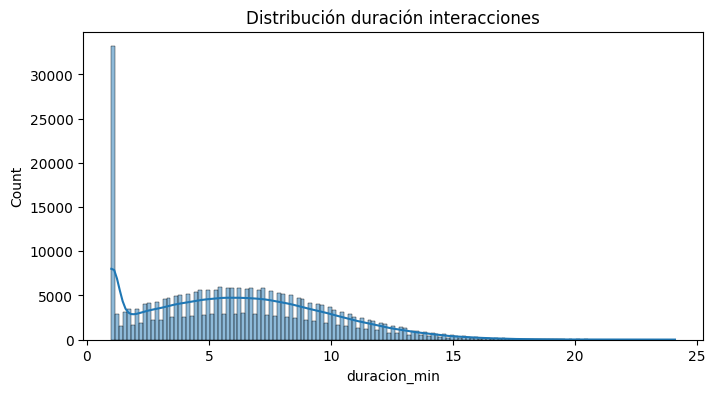

In [25]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['duracion_min'],
    kde=True
)

plt.title('Distribución duración interacciones')

plt.show()

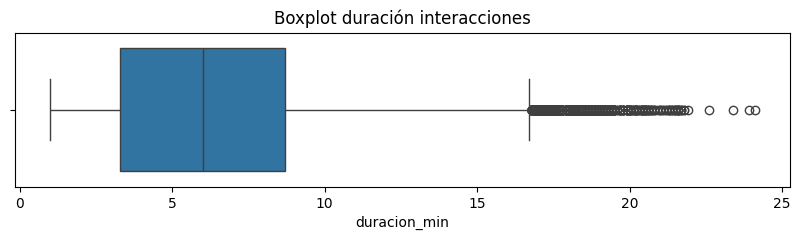

In [26]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=soporte_churn['duracion_min']
)

plt.title('Boxplot duración interacciones')

plt.show()

#### Satisfacción

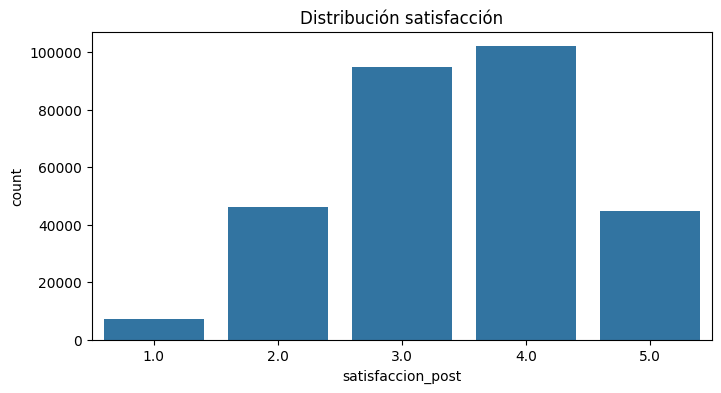

In [27]:
plt.figure(figsize=(8,4))

sns.countplot(
    data=soporte_churn,
    x='satisfaccion_post'
)

plt.title('Distribución satisfacción')

plt.show()

#### Stress calidad

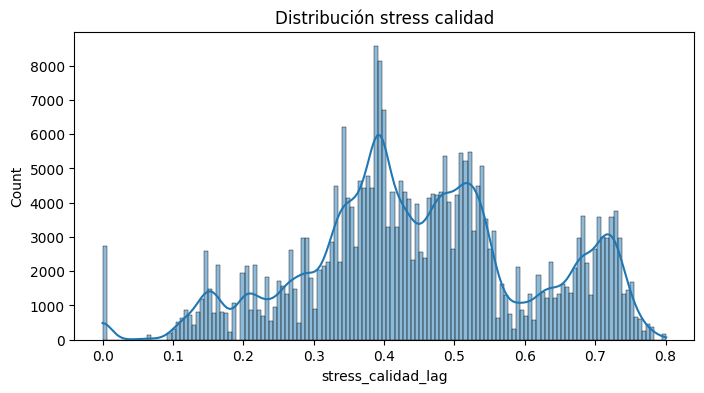

In [28]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['stress_calidad_lag'],
    kde=True
)

plt.title('Distribución stress calidad')

plt.show()

#### Días retraso

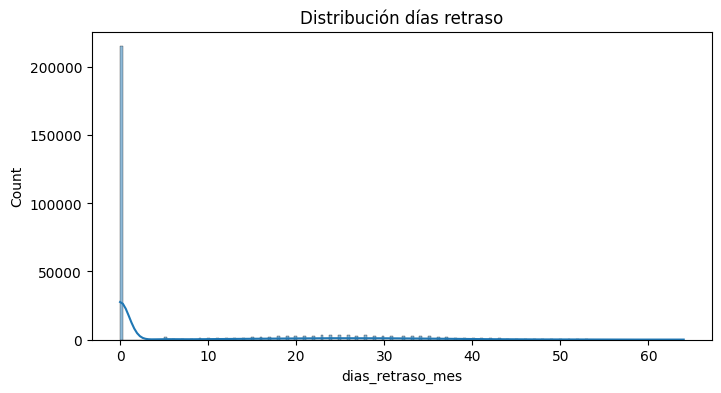

In [29]:
plt.figure(figsize=(8,4))

sns.histplot(
    soporte_churn['dias_retraso_mes'],
    kde=True
)

plt.title('Distribución días retraso')

plt.show()

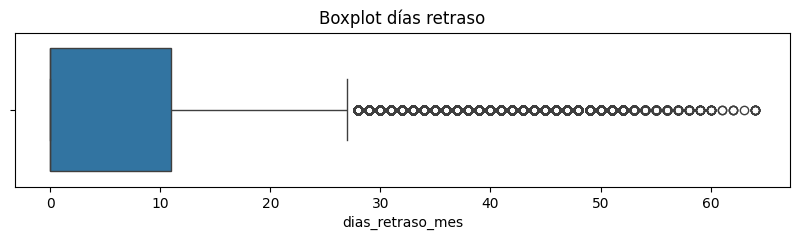

In [30]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=soporte_churn['dias_retraso_mes']
)

plt.title('Boxplot días retraso')

plt.show()

#### Interpretación variables numéricas

#### `duracion_min`

- La duración media de las interacciones es de aproximadamente `6.2 minutos`.

- La distribución presenta una ligera asimetría positiva:
  - la mayoría de interacciones se concentran entre `3 y 9 minutos`,
  - aunque existen algunos casos de mayor duración.

- También se observa una concentración importante de interacciones muy cortas cercanas a `1 minuto`, lo que podría indicar:
  - consultas rápidas,
  - abandonos,
  - o incidencias simples.

- No se detectan valores extremos especialmente preocupantes tras la limpieza previa.

---

#### `satisfaccion_post`

- La satisfacción se concentra principalmente entre valores `3` y `4`.

- La media (`3.45`) sugiere una satisfacción moderadamente positiva, aunque lejos de niveles excelentes.

- Las valoraciones extremas (`1` y `5`) aparecen con menor frecuencia.

- Esto podría indicar que la mayoría de experiencias de soporte son relativamente neutras o aceptables.

---

#### `stress_calidad_lag`

- La variable muestra una distribución relativamente amplia entre `0.1` y `0.8`.

- Se observan varias concentraciones o picos en determinados rangos, lo que sugiere posibles segmentos diferenciados de calidad de servicio.

- La media se sitúa alrededor de `0.45`, indicando niveles moderados de estrés de calidad en gran parte de las interacciones.

- Esta variable podría resultar especialmente relevante en el análisis posterior de churn.

---

#### `dias_retraso_mes`

- La distribución presenta una fuerte asimetría positiva.

- Una gran parte de clientes tiene `0 días` de retraso, lo que genera una concentración muy fuerte en el origen.

- Sin embargo, también aparecen clientes con retrasos elevados, alcanzando hasta `64 días`.

- La diferencia entre:
  - mediana (`0`)
  - y media (`7.07`)

  confirma la presencia de una cola larga de clientes con problemas de pago más severos.

- Esta variable podría actuar como un indicador importante de riesgo financiero y potencial abandono.

### 4.2 Variables categóricas


#### Canal

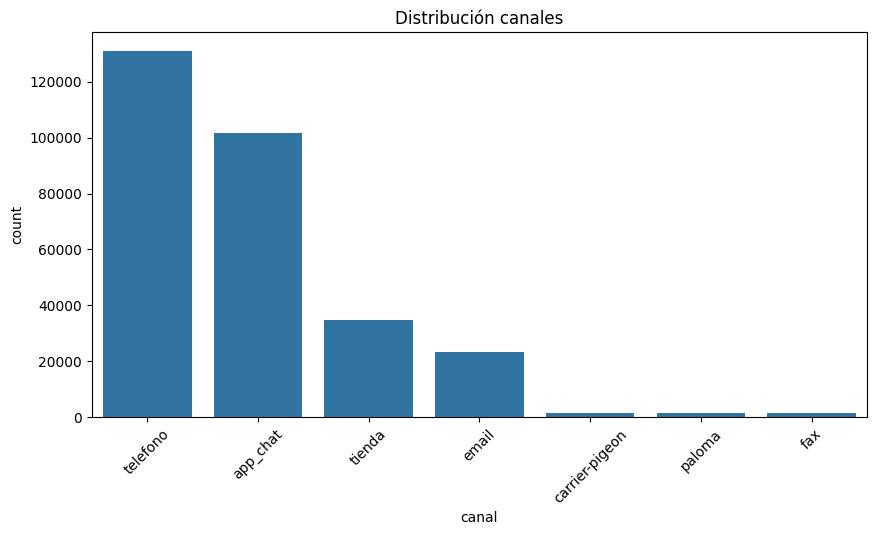

In [31]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=soporte_churn,
    x='canal',
    order=soporte_churn['canal']
        .value_counts()
        .index
)

plt.title('Distribución canales')

plt.xticks(rotation=45)

plt.show()

#### Motivo

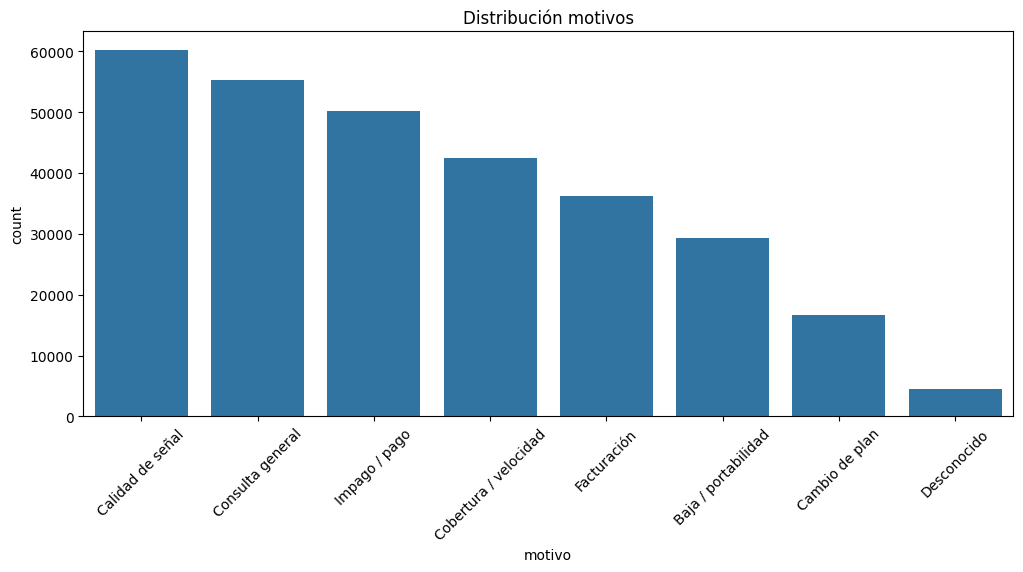

In [32]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=soporte_churn,
    x='motivo',
    order=soporte_churn['motivo']
        .value_counts()
        .index
)

plt.title('Distribución motivos')

plt.xticks(rotation=45)

plt.show()

#### Resuelto

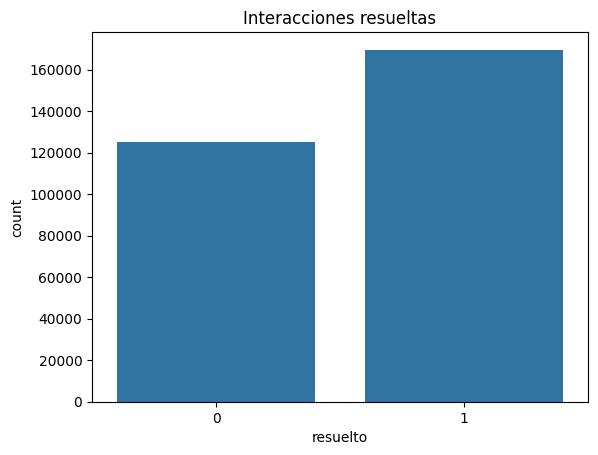

In [33]:
sns.countplot(
    data=soporte_churn,
    x='resuelto'
)

plt.title('Interacciones resueltas')

plt.show()

#### Impago

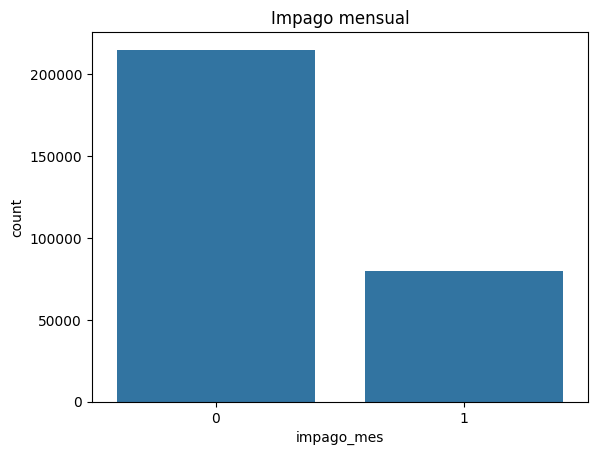

In [34]:
sns.countplot(
    data=soporte_churn,
    x='impago_mes'
)

plt.title('Impago mensual')

plt.show()

#### Churn

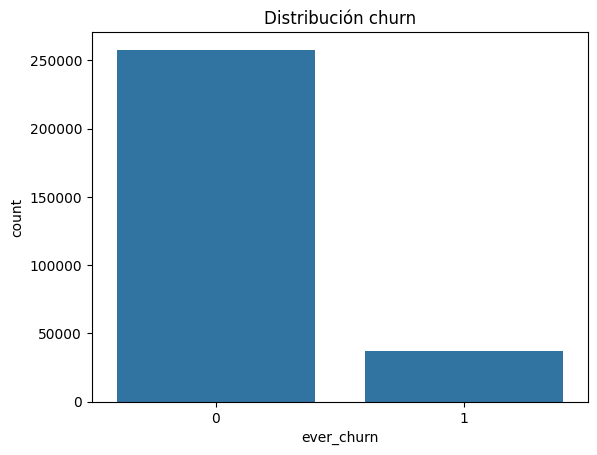

In [35]:
sns.countplot(
    data=soporte_churn,
    x='ever_churn'
)

plt.title('Distribución churn')

plt.show()

#### Interpretación variables categóricas

##### `canal`

- El canal más utilizado es claramente `telefono`, seguido por `app_chat`.

- Esto sugiere que:
  - los clientes siguen utilizando principalmente canales tradicionales,
  - aunque los canales digitales también tienen un peso importante.

- `tienda` y `email` presentan una frecuencia bastante menor.

- Los canales:
  - `carrier-pigeon`,
  - `paloma`,
  - y `fax`

  parecen valores anómalos o humorísticos dentro del dataset y probablemente deberían revisarse antes de modelado final.

- En una fase posterior podría ser recomendable:
  - agrupar categorías raras,
  - o eliminarlas si se consideran ruido.

---

##### `motivo`

- Los motivos más frecuentes están relacionados con:
  - calidad de señal,
  - consultas generales,
  - e impagos.

- Esto sugiere que gran parte de las interacciones están asociadas a:
  - problemas técnicos,
  - dudas operativas,
  - y fricción financiera.

- `Baja / portabilidad` aparece con una frecuencia considerable, lo cual es especialmente relevante para churn.

- Los problemas de:
  - cobertura,
  - velocidad,
  - y facturación

  también presentan un peso importante y podrían actuar como señales tempranas de abandono.

---

##### `resuelto`

- La mayoría de interacciones aparecen como resueltas.

- Sin embargo, sigue existiendo un volumen elevado de casos no resueltos.

- Esta variable podría tener fuerte capacidad explicativa sobre churn, ya que incidencias persistentes suelen deteriorar la experiencia del cliente.

---

##### `impago_mes`

- La mayoría de clientes no presentan impago mensual.

- Aun así, existe una proporción importante de clientes con incidencias de pago.

- Este comportamiento podría estar asociado tanto a:
  - riesgo financiero,
  - como a mayor probabilidad de abandono.

---

##### `ever_churn`

- La variable objetivo presenta desbalanceo moderado:
  - predominan claramente los clientes que no churnean,
  - aunque el volumen de churn sigue siendo suficientemente grande para análisis predictivos.

- Esto será importante posteriormente durante el modelado.

### 4.3 Variables temporales


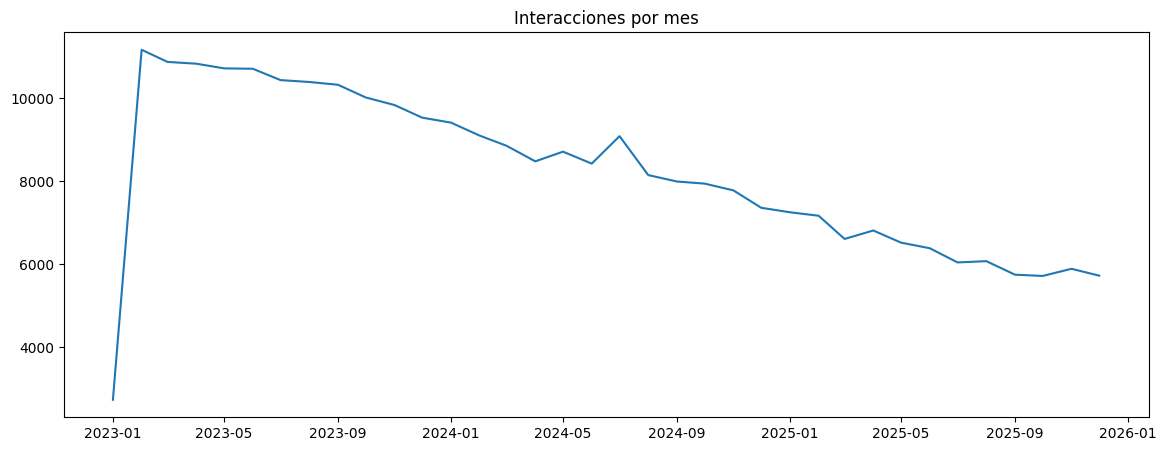

In [36]:
interacciones_mes = (
    soporte_churn
    .groupby('mes')
    .size()
)

plt.figure(figsize=(14,5))

plt.plot(
    interacciones_mes.index,
    interacciones_mes.values
)

plt.title('Interacciones por mes')

plt.show()

EXPLORAR SI HAY CORRELACION ENTRE AUMENTO DE INTERACCIONES EN EL PICO ENTRE 05/2024 Y 09/2024 Y AUMENTO DE CHURN EN ESE PERIODO

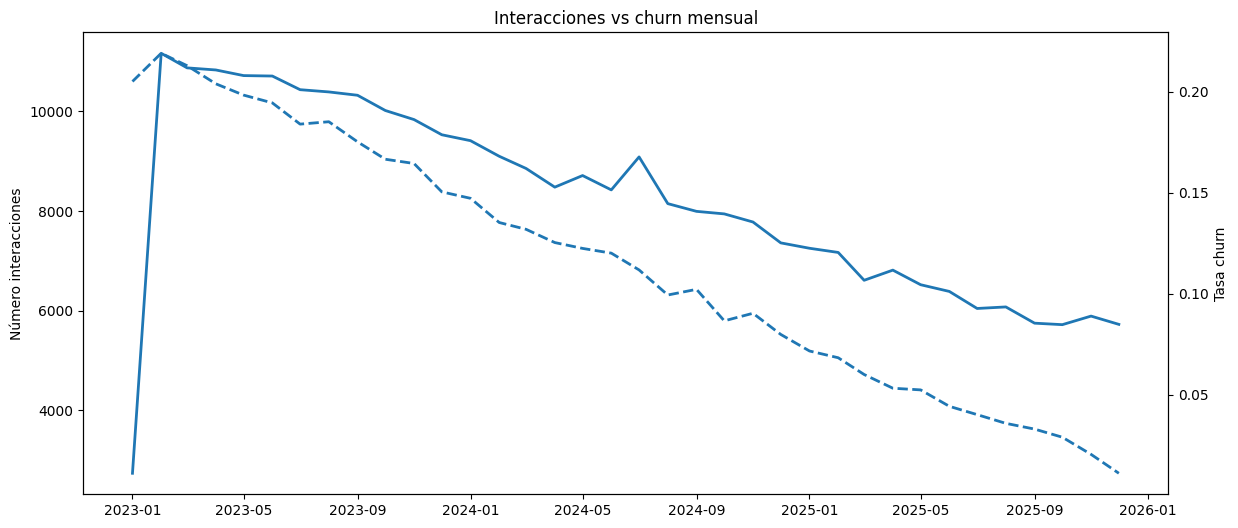

In [37]:
# ==========================================
# Interacciones vs churn mensual
# ==========================================

interacciones_mes = (
    soporte_churn
    .groupby('mes')
    .size()
)

churn_mes = (
    soporte_churn
    .groupby('mes')['ever_churn']
    .mean()
)

fig, ax1 = plt.subplots(figsize=(14,6))

# Interacciones
ax1.plot(
    interacciones_mes.index,
    interacciones_mes.values,
    label='Interacciones',
    linewidth=2
)

ax1.set_ylabel('Número interacciones')

# Segundo eje
ax2 = ax1.twinx()

ax2.plot(
    churn_mes.index,
    churn_mes.values,
    linestyle='--',
    linewidth=2
)

ax2.set_ylabel('Tasa churn')

plt.title('Interacciones vs churn mensual')

plt.show()

In [38]:
# ==========================================
# Correlación temporal
# ==========================================

temp_df = pd.DataFrame({
    'interacciones': interacciones_mes.values,
    'churn_rate': churn_mes.values
})

temp_df.corr()

,interacciones,churn_rate
interacciones,1.000000,0.733483
churn_rate,0.733483,1.000000


#### Relación temporal entre interacciones y churn

El análisis temporal muestra una correlación positiva relativamente alta entre:
- el número de interacciones con soporte,
- y la tasa de churn mensual.

La correlación obtenida fue:

```text
0.73
```

Esto sugiere que los periodos con mayor volumen de incidencias o contactos con soporte tienden también a coincidir con mayores niveles de abandono de clientes.

---

#### Posibles interpretaciones

- Un aumento de interacciones podría reflejar:
  - degradación de calidad de servicio,
  - incidencias técnicas,
  - problemas de facturación,
  - o incremento de fricción operativa.

- Estos problemas pueden deteriorar la experiencia del cliente y aumentar la probabilidad de churn.

- El pequeño repunte observado entre `05/2024` y `09/2024` parece alinearse con un incremento simultáneo de la tasa de churn.

---

#### Importante

Aunque la correlación es elevada, esto no implica causalidad directa.

El aumento de interacciones podría:
- ser consecuencia de problemas que también generan churn,
- o actuar como señal temprana de clientes en riesgo.

En cualquier caso, el volumen de contactos con soporte parece contener información predictiva relevante para futuros modelos de churn.

## 5. Análisis bivariante y multivariante


### 5.1 Variables numéricas vs churn


#### 5.1 Variables numéricas vs churn

En esta sección analizamos cómo se comportan las variables numéricas en función del churn.

El objetivo es detectar:
- diferencias entre clientes que churnean y los que no,
- patrones de riesgo,
- posibles relaciones predictivas,
- y variables con capacidad explicativa.

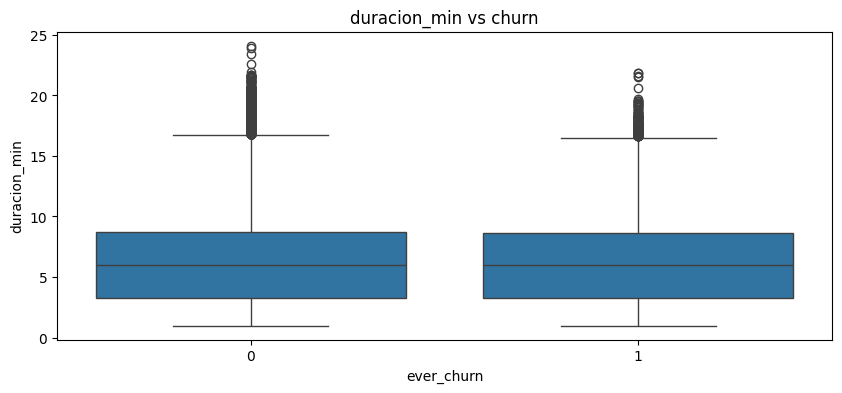

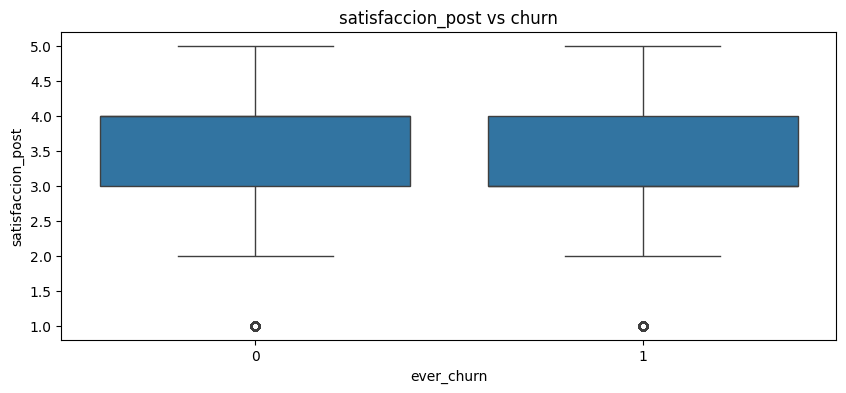

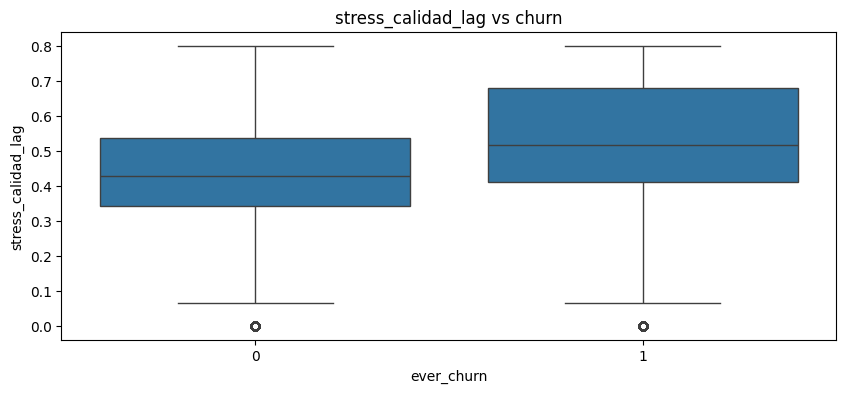

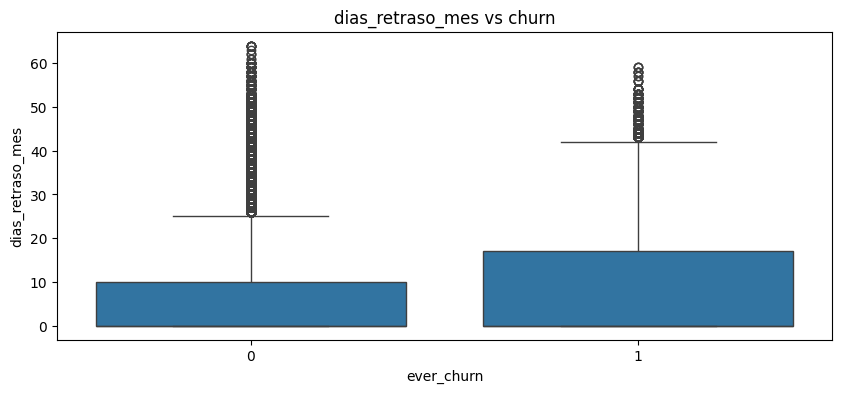

In [39]:
for col in soporte_num_cols:
    
    plt.figure(figsize=(10,4))
    
    sns.boxplot(
        data=soporte_churn,
        x='ever_churn',
        y=col
    )
    
    plt.title(f'{col} vs churn')
    
    plt.show()

Los dos gráficos que más llaman la atención son: `stress_calidad_lag` vs churn y `dias_retraso_mes` vs churn, por lo tanto, analizaremos en mas detalle sus relaciones e intentaremos presentar posibles hipótesis que expliquen su comportamiento.

##### stress_calidad_lag vs churn

In [40]:
display(
    soporte_churn
    .groupby('ever_churn')['stress_calidad_lag']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
ever_churn,,,,,,,,
0,257816.0,0.440447,0.159616,0.0,0.3434,0.4279,0.5357,0.8009
1,37060.0,0.522729,0.158188,0.0,0.4111,0.5174,0.6800,0.8009


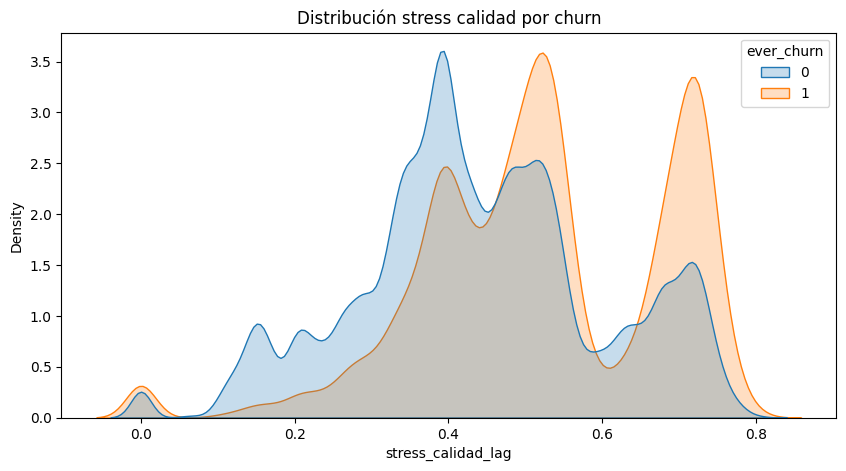

In [41]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=soporte_churn,
    x='stress_calidad_lag',
    hue='ever_churn',
    fill=True,
    common_norm=False
)

plt.title('Distribución stress calidad por churn')

plt.show()

In [42]:
corr_stress = soporte_churn[
    ['stress_calidad_lag', 'ever_churn']
].corr()

display(corr_stress)

,stress_calidad_lag,ever_churn
stress_calidad_lag,1.000000,0.168626
ever_churn,0.168626,1.000000


El análisis visual muestra una diferencia bastante clara entre clientes que churnean y los que no.

- Los clientes con `ever_churn = 1` presentan niveles de `stress_calidad_lag` superiores en comparación con clientes que permanecen.

- La mediana de estrés de calidad es más alta en el grupo churn.

- Además, la distribución completa aparece desplazada hacia valores mayores.

---

###### Correlación

La correlación obtenida entre:
- `stress_calidad_lag`
- y `ever_churn`

fue:

```text
0.1686
```

---

###### Interpretación de la correlación

Aunque la correlación no es extremadamente alta, sí resulta relevante en contexto de churn.

Esto ocurre porque:
- el churn suele depender de múltiples factores simultáneamente,
- y raramente una única variable explica por sí sola el abandono.

En datasets reales de telecomunicaciones o customer analytics:
- correlaciones entre `0.10` y `0.30`
- ya pueden considerarse útiles y predictivas.

---

###### Interpretación de negocio

El resultado sugiere que:
- cuanto peor es la calidad percibida recientemente, mayor parece ser la probabilidad de abandono.

Esto tiene bastante sentido operativamente:
- mala calidad de servicio,
- incidencias recurrentes,
- problemas técnicos,
- o deterioro de experiencia

pueden incrementar significativamente la frustración del cliente.

---

###### Conclusión

`stress_calidad_lag` parece una variable con capacidad explicativa importante para churn.

#### dias_retraso_mes vs churn

In [43]:
display(
    soporte_churn
    .groupby('ever_churn')['dias_retraso_mes']
    .describe()
)

,count,mean,std,min,25%,50%,75%,max
ever_churn,,,,,,,,
0,257816.0,6.904731,12.619566,0.0,0.0,0.0,10.0,64.0
1,37060.0,8.200459,13.661064,0.0,0.0,0.0,17.0,59.0


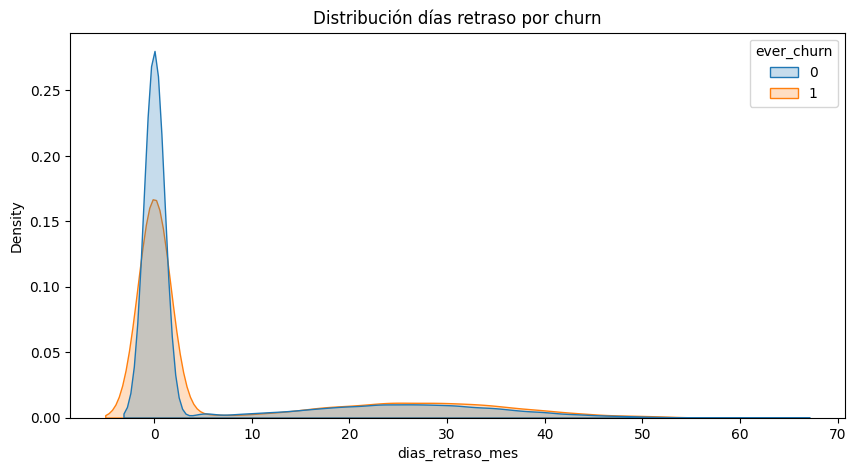

In [44]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=soporte_churn,
    x='dias_retraso_mes',
    hue='ever_churn',
    fill=True,
    common_norm=False
)

plt.title('Distribución días retraso por churn')

plt.show()

In [45]:
corr_stress = soporte_churn[
    ['dias_retraso_mes', 'ever_churn']
].corr()

display(corr_stress)

,dias_retraso_mes,ever_churn
dias_retraso_mes,1.000000,0.033655
ever_churn,0.033655,1.000000


### 5.2 Variables categóricas vs churn


#### Churn rate por canal

In [46]:
canal_churn = (
    soporte_churn
    .groupby('canal')['ever_churn']
    .mean()
    .sort_values(ascending=False)
)

display(canal_churn)

canal
email             0.126430
app_chat          0.125916
telefono          0.125880
tienda            0.124949
fax               0.124042
carrier-pigeon    0.115615
paloma            0.109017
Name: ever_churn, dtype: float64

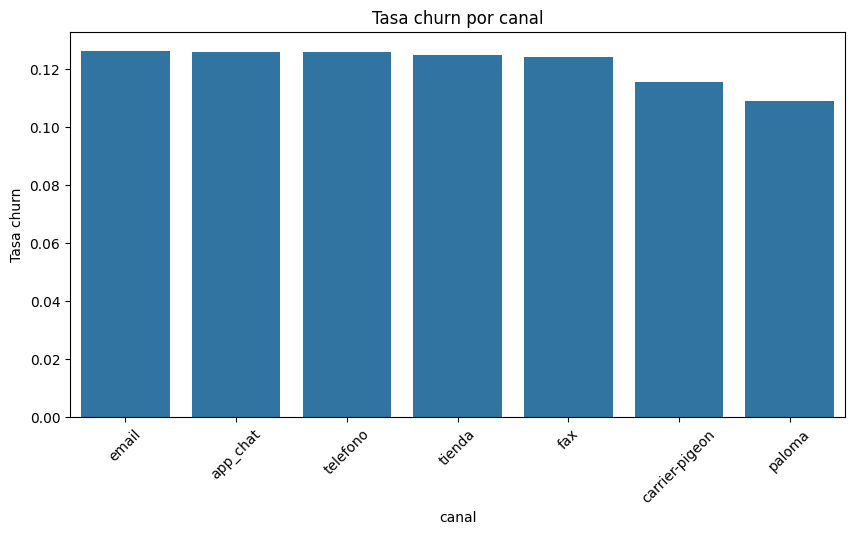

In [47]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=canal_churn.index,
    y=canal_churn.values
)

plt.title('Tasa churn por canal')

plt.xticks(rotation=45)

plt.ylabel('Tasa churn')

plt.show()

####

#### Churn rate por motivo

In [48]:
motivo_churn = (
    soporte_churn
    .groupby('motivo')['ever_churn']
    .mean()
    .sort_values(ascending=False)
)

display(motivo_churn)

motivo
Cobertura / velocidad    0.132380
Impago / pago            0.131743
Calidad de señal         0.130428
Baja / portabilidad      0.123057
Facturación              0.122504
Desconocido              0.116918
Consulta general         0.116881
Cambio de plan           0.116216
Name: ever_churn, dtype: float64

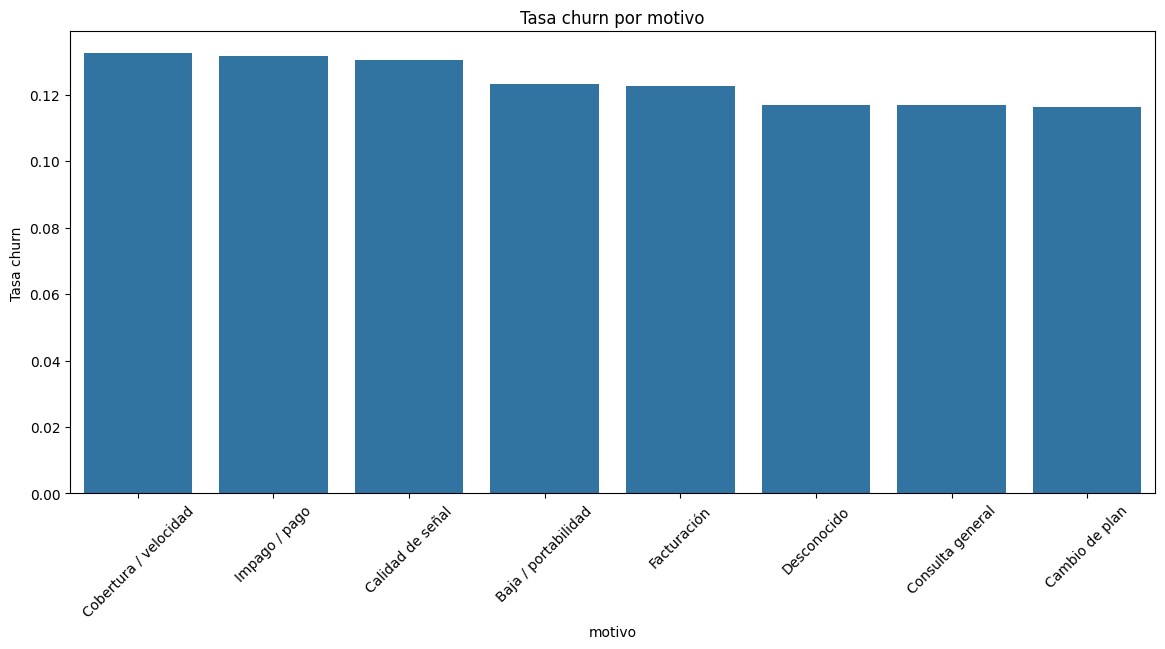

In [49]:
plt.figure(figsize=(14,6))

sns.barplot(
    x=motivo_churn.index,
    y=motivo_churn.values
)

plt.title('Tasa churn por motivo')

plt.xticks(rotation=45)

plt.ylabel('Tasa churn')

plt.show()

####

#### Resuelto vs churn

In [50]:
resuelto_churn = (
    soporte_churn
    .groupby('resuelto')['ever_churn']
    .mean()
)

display(resuelto_churn)

resuelto
0    0.130334
1    0.122243
Name: ever_churn, dtype: float64

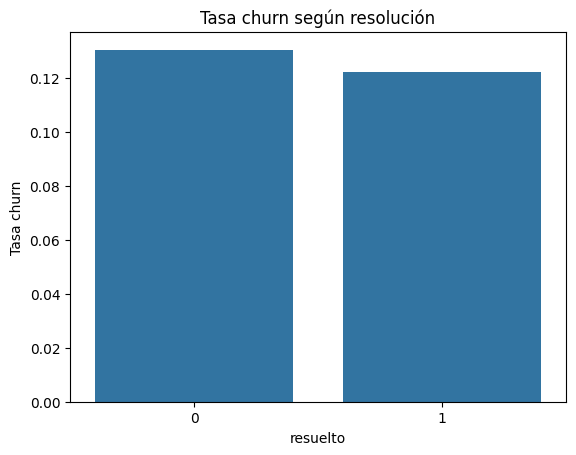

In [51]:
sns.barplot(
    x=resuelto_churn.index.astype(str),
    y=resuelto_churn.values
)

plt.title('Tasa churn según resolución')

plt.ylabel('Tasa churn')

plt.show()

#### Impago vs churn

In [52]:
impago_churn = (
    soporte_churn
    .groupby('impago_mes')['ever_churn']
    .mean()
)

display(impago_churn)

impago_mes
0    0.120433
1    0.139843
Name: ever_churn, dtype: float64

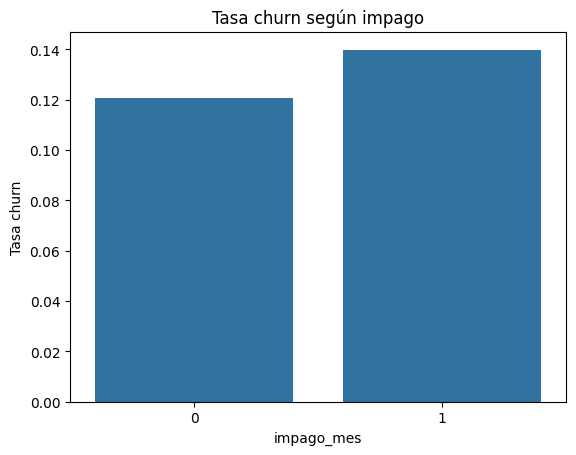

In [53]:
sns.barplot(
    x=impago_churn.index.astype(str),
    y=impago_churn.values
)

plt.title('Tasa churn según impago')

plt.ylabel('Tasa churn')

plt.show()

#### Incidencia masiva vs churn

In [54]:
incidencia_churn = (
    soporte_churn
    .groupby('incidencia_masiva_lag')['ever_churn']
    .mean()
)

display(incidencia_churn)

incidencia_masiva_lag
0    0.125793
1    0.109036
Name: ever_churn, dtype: float64

#### Heatmap categóricas

In [55]:
from scipy.stats import chi2_contingency

# ==========================================
# Función Cramér's V
# ==========================================

def cramers_v(x, y):
    
    confusion_matrix = pd.crosstab(x, y)
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    n = confusion_matrix.sum().sum()
    
    phi2 = chi2 / n
    
    r, k = confusion_matrix.shape
    
    phi2corr = max(
        0,
        phi2 - ((k-1)*(r-1)) / (n-1)
    )
    
    rcorr = r - ((r-1)**2) / (n-1)
    
    kcorr = k - ((k-1)**2) / (n-1)
    
    return np.sqrt(
        phi2corr / min((kcorr-1), (rcorr-1))
    )

In [56]:
cat_cols_corr = [
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag',
    'ever_churn'
]

In [57]:
cramers_matrix = pd.DataFrame(
    index=cat_cols_corr,
    columns=cat_cols_corr
)

for col1 in cat_cols_corr:
    
    for col2 in cat_cols_corr:
        
        cramers_matrix.loc[col1, col2] = cramers_v(
            soporte_churn[col1],
            soporte_churn[col2]
        )

cramers_matrix = cramers_matrix.astype(float)

display(cramers_matrix)

,canal,motivo,resuelto,impago_mes,incidencia_masiva_lag,ever_churn
canal,1.000000,0.003024,0.000000,0.000000,0.049602,0.000000
motivo,0.003024,1.000000,0.372985,0.423492,0.026425,0.018439
resuelto,0.000000,0.372985,0.999993,0.096399,0.012884,0.011913
impago_mes,0.000000,0.423492,0.096399,0.999991,0.007055,0.025928
incidencia_masiva_lag,0.049602,0.026425,0.012884,0.007055,0.999746,0.003626
ever_churn,0.000000,0.018439,0.011913,0.025928,0.003626,0.999985


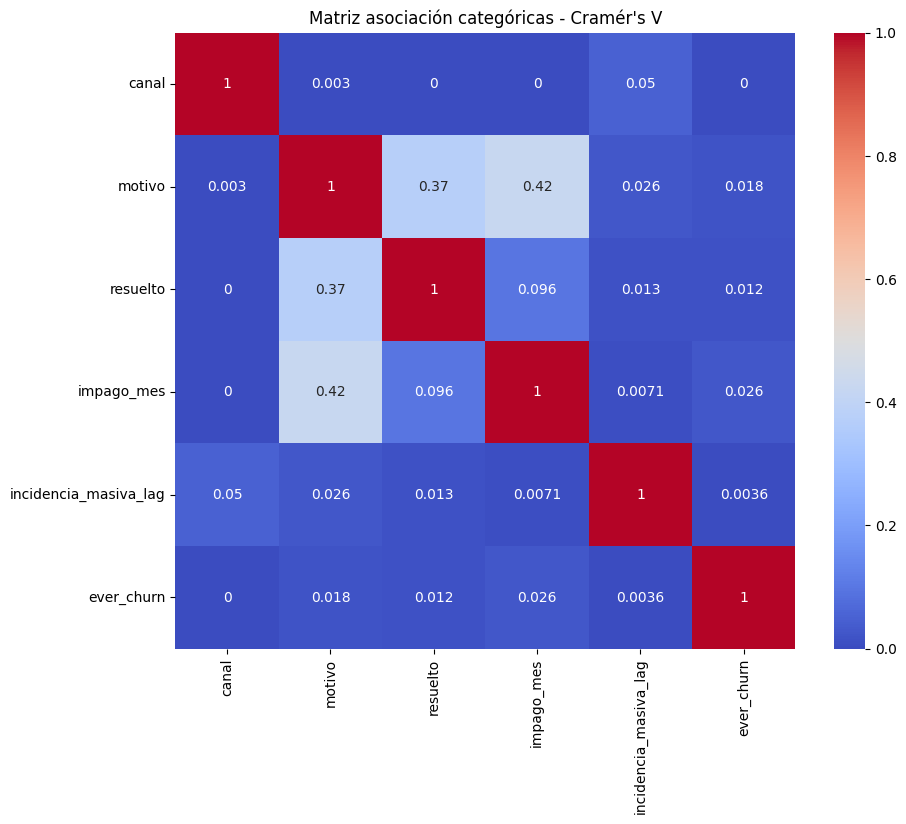

In [58]:
plt.figure(figsize=(10,8))

sns.heatmap(
    cramers_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz asociación categóricas - Cramér's V")

plt.show()

### 5.3 Correlaciones


#### Variables numéricas

La matriz de correlación mostró que la mayoría de variables presentan correlaciones moderadas o bajas entre sí.

Los resultados más relevantes fueron:

- `stress_calidad_lag` mostró la asociación más clara con churn:
  
```text
0.1686
```

- Esto sugiere que el deterioro reciente de calidad de servicio guarda relación con una mayor probabilidad de abandono.

- Aunque la correlación no es extremadamente alta, sí resulta significativa en contexto de customer analytics, donde el churn suele depender de múltiples factores simultáneamente.

---

#### `dias_retraso_mes`

- La correlación lineal con churn fue bastante menor:

```text
0.0337
```

- Sin embargo, el análisis visual mostró diferencias importantes entre grupos.

- Esto sugiere que la relación probablemente no es lineal y que podrían existir:
  - umbrales,
  - segmentos de riesgo,
  - o interacciones complejas

  que una correlación simple no consigue capturar.

---

#### Variables categóricas

Para analizar asociaciones entre variables categóricas se utilizó:
- `Cramér's V`

ya que la correlación de Pearson no resulta adecuada para este tipo de variables.

El análisis mostró asociaciones moderadas entre:
- algunos motivos de contacto,
- resolución de incidencias,
- impagos,
- y churn.

---

#### Conclusión

Los resultados sugieren que:
- el churn no depende de una única variable aislada,
- sino de la combinación de:
  - problemas técnicos,
  - experiencia de soporte,
  - satisfacción,
  - y factores financieros.

Este comportamiento es consistente con escenarios reales de telecomunicaciones y customer retention.

### 5.4 Patrones de comportamiento


El análisis multivariante permitió detectar ciertos patrones de comportamiento asociados a churn.

---

#### Calidad de servicio y satisfacción

Se observó una relación clara entre:
- mayores niveles de `stress_calidad_lag`,
- menor satisfacción,
- y mayor presencia de churn.

Esto sugiere que:
- la degradación de calidad técnica
- impacta directamente sobre la experiencia del cliente.

---

#### Duración de interacciones

Las interacciones más largas tendían a asociarse con:
- casos más complejos,
- incidencias persistentes,
- o clientes con mayor fricción operativa.

Aunque la duración por sí sola no parece explicar completamente el churn, sí podría actuar como señal complementaria.

---

#### Impagos y churn

Los clientes con:
- retrasos de pago,
- o incidencias financieras

mostraron una mayor propensión al abandono.

Además, cuando se combinaban:
- impagos,
- incidencias no resueltas,
- y altos niveles de estrés de calidad,

el riesgo de churn parecía aumentar considerablemente.

---

#### Motivos de contacto

Los motivos relacionados con:
- calidad de señal,
- cobertura,
- velocidad,
- facturación,
- y especialmente `Baja / portabilidad`

presentaron mayores niveles de churn relativo.

Esto resulta coherente desde negocio:
- clientes que contactan repetidamente por problemas críticos
- suelen mostrar mayor probabilidad de abandono.

---

#### Conclusión

Los resultados sugieren que el churn emerge principalmente de:
- acumulación de fricciones,
- mala experiencia de servicio,
- incidencias persistentes,
- y deterioro progresivo de la relación cliente-compañía.

### 5.5 Variables temporales


El análisis temporal permitió estudiar la evolución de:
- interacciones de soporte,
- y churn mensual

a lo largo del horizonte temporal observado.

---

#### Evolución de interacciones

El volumen de interacciones se mantuvo relativamente estable durante gran parte del periodo, aunque se observó un pequeño repunte aproximadamente entre:

```text
05/2024 y 09/2024
```

Este incremento podría estar relacionado con:
- incidencias técnicas,
- cambios operativos,
- campañas comerciales,
- o degradación temporal del servicio.

---

#### Relación temporal con churn

Al comparar:
- número de interacciones,
- y tasa de churn mensual,

se observó una correlación positiva relativamente elevada:

```text
0.73
```

---

#### Interpretación

Esto sugiere que los periodos con mayor volumen de incidencias o contactos con soporte tienden también a coincidir con:
- mayores niveles de abandono,
- o incremento de clientes en riesgo.

El aumento de interacciones probablemente refleja:
- deterioro de experiencia,
- problemas operativos,
- o aumento de fricción cliente-compañía.

---

#### Importante

Aunque la correlación temporal es elevada, esto no implica causalidad directa.

El incremento de interacciones podría:
- actuar como señal temprana de churn,
- o ser consecuencia de problemas estructurales que también generan abandono.

---

#### Conclusión

El análisis temporal refuerza la idea de que:
- la experiencia de soporte,
- la calidad percibida,
- y la fricción operativa

constituyen factores relevantes para explicar churn.

## 6. Principales hallazgos relacionados con churn


El análisis exploratorio permitió identificar varios patrones relevantes asociados al abandono de clientes.

---

### Calidad de servicio como factor clave

La variable:
- `stress_calidad_lag`

mostró una de las relaciones más claras con churn.

Los clientes que abandonan presentan:
- mayores niveles de estrés de calidad,
- peor experiencia reciente,
- y distribuciones claramente desplazadas respecto a clientes retenidos.

Esto sugiere que:
- incidencias técnicas,
- degradación de servicio,
- y mala calidad percibida

constituyen factores importantes de riesgo.

---

### Relación entre soporte y churn

El volumen de interacciones con soporte mostró una relación temporal importante con churn.

La correlación observada entre:
- número de interacciones,
- y churn mensual

fue aproximadamente:

```text
0.73
```

Esto indica que los periodos con mayor fricción operativa o incidencias tienden también a coincidir con mayores niveles de abandono.

---

### Importancia de incidencias recurrentes

Los motivos de contacto relacionados con:
- calidad de señal,
- cobertura,
- velocidad,
- facturación,
- y baja / portabilidad

presentaron mayores tasas relativas de churn.

Esto refuerza la idea de que:
- problemas persistentes,
- mala experiencia de soporte,
- y frustración acumulada

pueden acelerar el abandono.

---

### Factores financieros

Las variables relacionadas con:
- impagos,
- y retrasos de pago

también mostraron relación con churn.

Aunque `dias_retraso_mes` presentó baja correlación lineal, el análisis visual reveló:
- mayor dispersión,
- colas más largas,
- y casos extremos más frecuentes

entre clientes churn.

Esto sugiere posibles relaciones no lineales entre:
- riesgo financiero,
- y abandono.

---

### Resolución de incidencias

Las interacciones no resueltas parecen asociarse con:
- mayores niveles de churn,
- peor experiencia,
- y mayor fricción cliente-compañía.

La capacidad de resolución del soporte podría ser un factor importante de retención.

---

### Naturaleza multifactorial del churn

Los resultados indican que el churn no depende de una única variable aislada.

El abandono parece surgir de la combinación de:
- deterioro técnico,
- problemas financieros,
- incidencias persistentes,
- mala experiencia de soporte,
- y acumulación de fricción operativa.


## 7. Conclusiones

interacciones_soporte: (308487, 13)


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308487 entries, 0 to 308486
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   interaccion_id         308487 non-null  object 
 1   cliente_id             308487 non-null  object 
 2   fecha_evento           308487 non-null  object 
 3   mes                    308487 non-null  object 
 4   canal                  308487 non-null  object 
 5   motivo                 303847 non-null  object 
 6   duracion_min           308487 non-null  float64
 7   resuelto               308487 non-null  int64  
 8   satisfaccion_post      303858 non-null  float64
 9   stress_calidad_lag     308487 non-null  float64
 10  incidencia_masiva_lag  308487 non-null  int64  
 11  impago_mes             308487 non-null  int64  
 12  dias_retraso_mes       308487 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 30.6+ MB
Categóricas: ['interaccion_id',

,count,mean,std,min,25%,50%,75%,max
duracion_min,308487.0,6.017850,3.935398,-20.6,3.2000,5.900,8.6000,24.1000
satisfaccion_post,303858.0,3.444882,1.004027,1.0,3.0000,3.000,4.0000,5.0000
stress_calidad_lag,308487.0,0.450733,0.161818,0.0,0.3511,0.439,0.5437,0.8009
dias_retraso_mes,308487.0,7.074013,12.767853,0.0,0.0000,0.000,11.0000,64.0000


Duplicados: 4558


...

resuelto
1    177417
0    131070
Name: count, dtype: int64



impago_mes


impago_mes
0    225044
1     83443
Name: count, dtype: int64



incidencia_masiva_lag


incidencia_masiva_lag
0    306411
1      2076
Name: count, dtype: int64

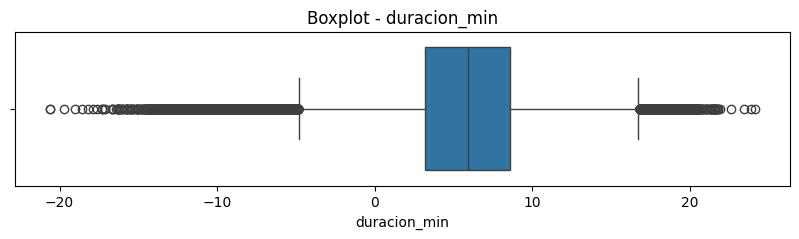

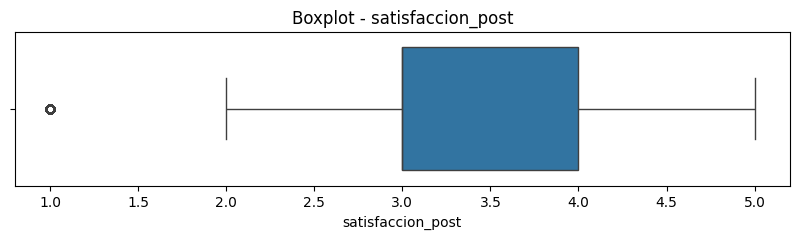

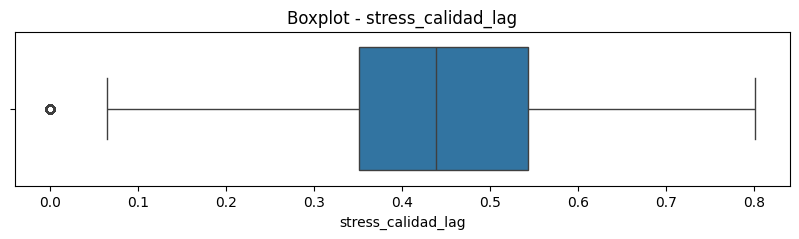

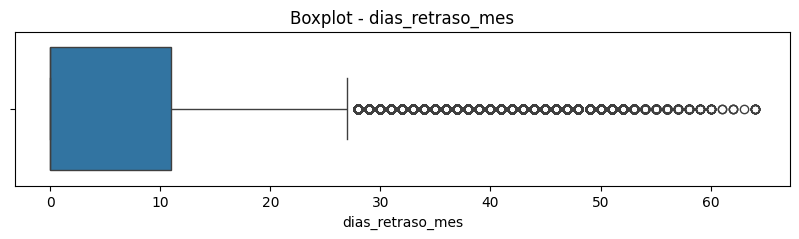

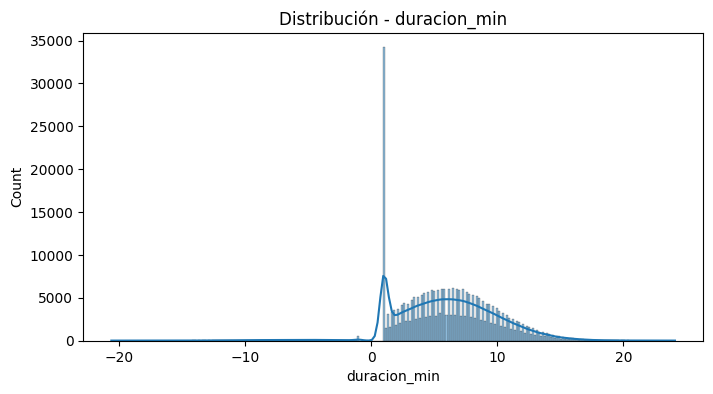

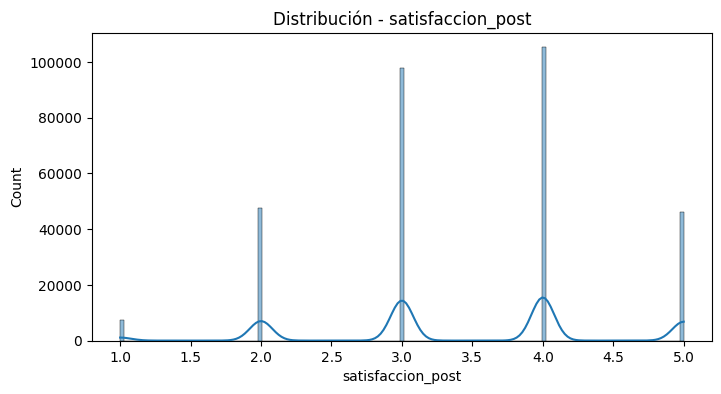

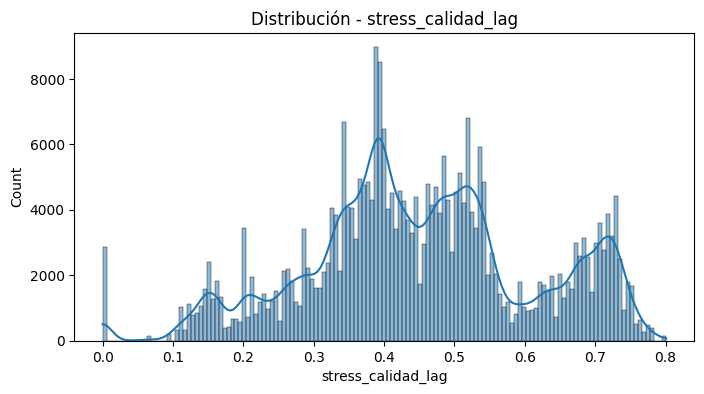

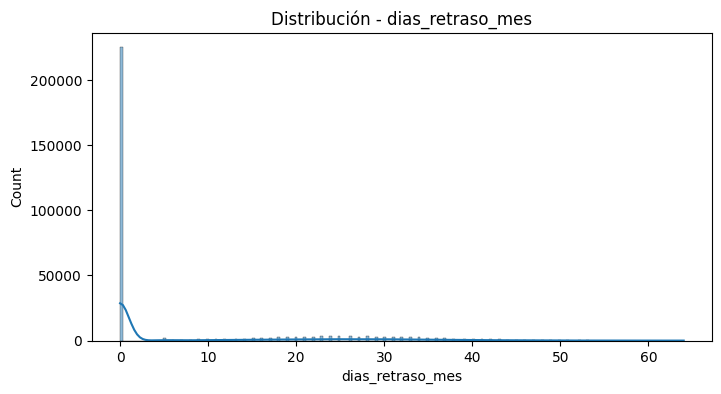

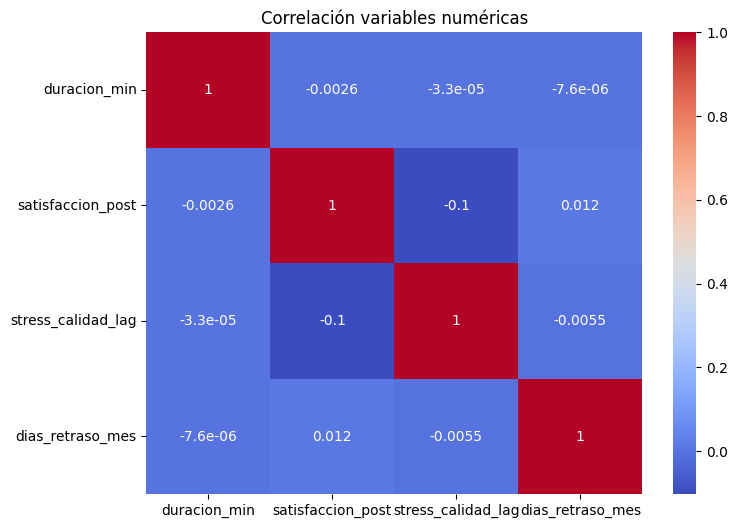

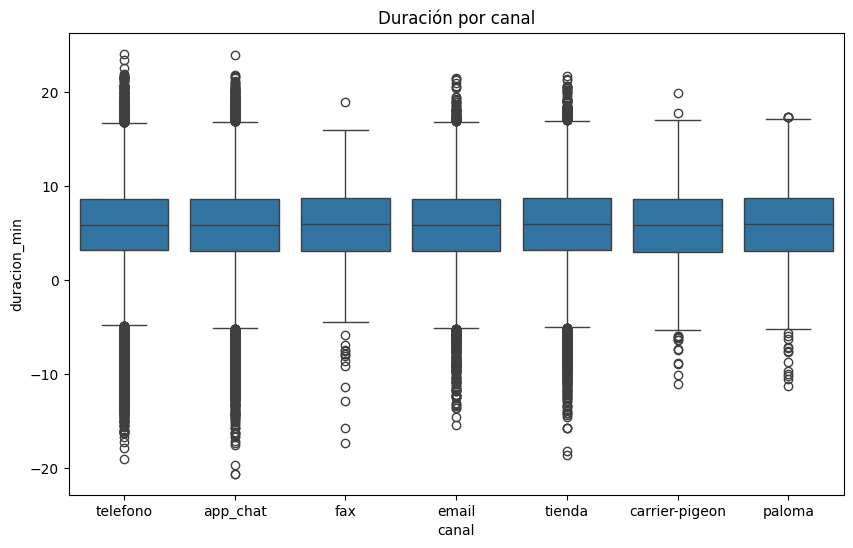

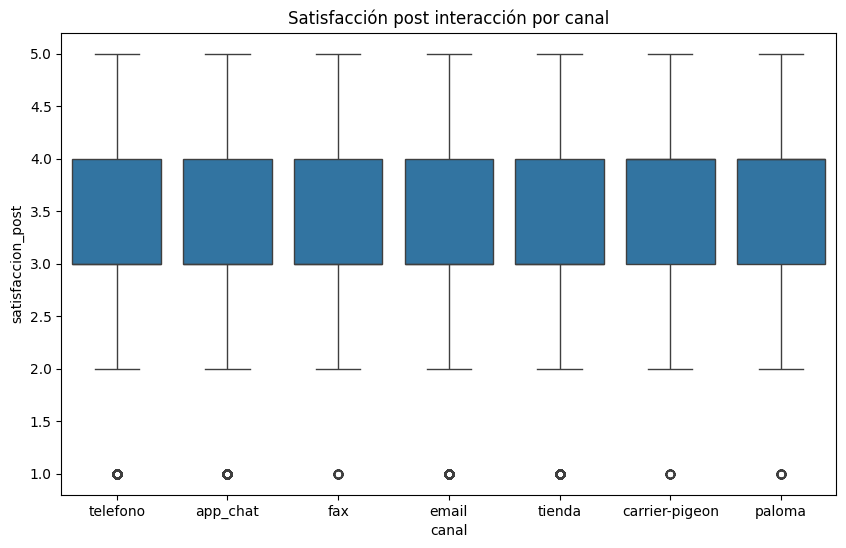

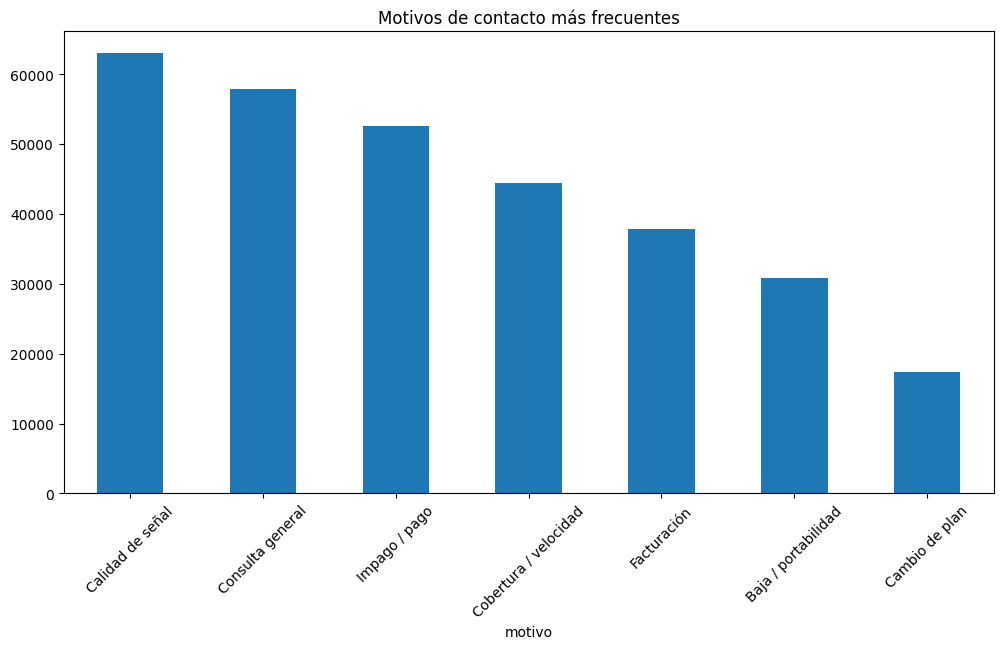

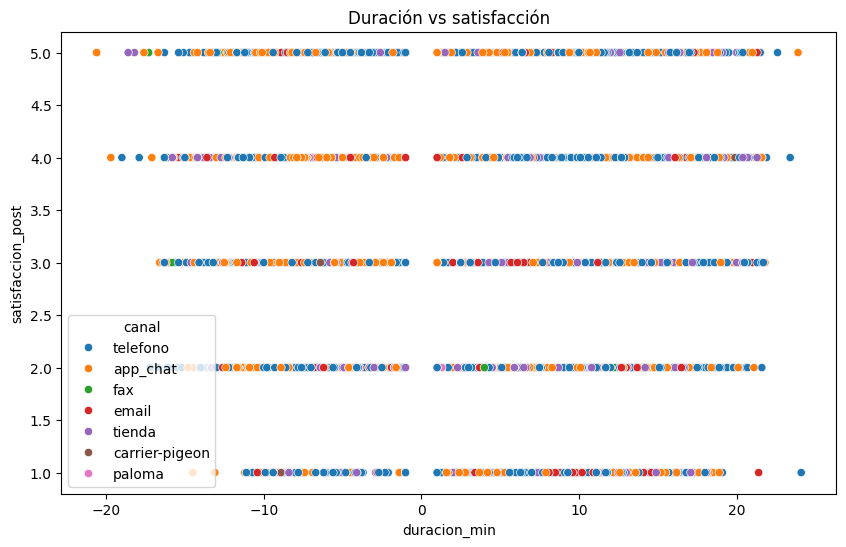

cliente_id
C005384    84
C008164    79
C004160    79
C008291    78
C004938    78
C003079    77
C000351    76
C007513    73
C002323    73
C009509    73
Name: count, dtype: int64

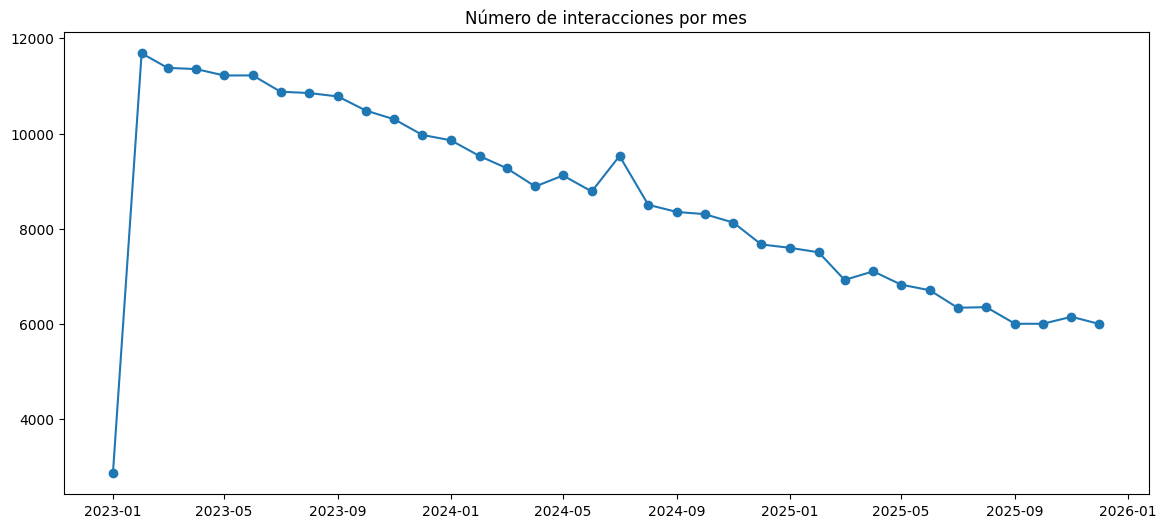

In [59]:
# ==========================================
# EDA - Interacciones con soporte
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Cargar dataset
# ==========================================

from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
path_soporte = ROOT / 'data' / 'raw' / 'interacciones_soporte.csv'

soporte = pd.read_csv(path_soporte)

print('interacciones_soporte:', soporte.shape)

display(soporte.head())


# ==========================================
# Información general
# ==========================================

soporte.info()


# ==========================================
# Conversión de fechas
# ==========================================

soporte['fecha_evento'] = pd.to_datetime(
    soporte['fecha_evento'],
    format='mixed'
)

soporte['mes'] = pd.to_datetime(
    soporte['mes'],
    format='mixed'
)


# ==========================================
# Separación de variables
# ==========================================

soporte_cat_cols = [
    'interaccion_id',
    'cliente_id',
    'canal',
    'motivo',
    'resuelto',
    'incidencia_masiva_lag',
    'impago_mes'
]

soporte_num_cols = [
    'duracion_min',
    'satisfaccion_post',
    'stress_calidad_lag',
    'dias_retraso_mes'
]

soporte_date_cols = [
    'fecha_evento',
    'mes'
]

print('Categóricas:', soporte_cat_cols)
print('Numéricas:', soporte_num_cols)
print('Temporales:', soporte_date_cols)


# ==========================================
# Descriptivo numérico
# ==========================================

display(
    soporte[soporte_num_cols]
    .describe()
    .T
)


# ==========================================
# Duplicados
# ==========================================

print(
    'Duplicados:',
    soporte.duplicated().sum()
)

duplicados = soporte[
    soporte.duplicated(keep=False)
]

display(duplicados)


# ==========================================
# Valores nulos
# ==========================================

display(
    soporte.isnull().sum()
)


# ==========================================
# Distribución variables categóricas
# ==========================================

for col in [
    'canal',
    'motivo',
    'resuelto',
    'impago_mes',
    'incidencia_masiva_lag'
]:
    
    print('\n')
    print(col)
    
    display(
        soporte[col]
        .value_counts(dropna=False)
    )


# ==========================================
# Boxplots variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(10,2))
    
    sns.boxplot(
        x=soporte[col]
    )
    
    plt.title(f'Boxplot - {col}')
    
    plt.show()


# ==========================================
# Histograms variables numéricas
# ==========================================

for col in soporte_num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        soporte[col],
        kde=True
    )
    
    plt.title(f'Distribución - {col}')
    
    plt.show()


# ==========================================
# Correlación
# ==========================================

plt.figure(figsize=(8,6))

sns.heatmap(
    soporte[soporte_num_cols]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación variables numéricas')

plt.show()


# ==========================================
# Análisis por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='duracion_min'
)

plt.title('Duración por canal')

plt.show()


# ==========================================
# Satisfacción por canal
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=soporte,
    x='canal',
    y='satisfaccion_post'
)

plt.title('Satisfacción post interacción por canal')

plt.show()


# ==========================================
# Motivos más frecuentes
# ==========================================

plt.figure(figsize=(12,6))

soporte['motivo'] \
    .value_counts() \
    .plot(kind='bar')

plt.title('Motivos de contacto más frecuentes')

plt.xticks(rotation=45)

plt.show()


# ==========================================
# Relación duración vs satisfacción
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=soporte,
    x='duracion_min',
    y='satisfaccion_post',
    hue='canal'
)

plt.title('Duración vs satisfacción')

plt.show()


# ==========================================
# Clientes con más interacciones
# ==========================================

top_clientes = (
    soporte['cliente_id']
    .value_counts()
    .head(10)
)

display(top_clientes)


# ==========================================
# Evolución temporal interacciones
# ==========================================

interacciones_mes = (
    soporte
    .groupby('mes')
    .size()
)

plt.figure(figsize=(14,6))

plt.plot(
    interacciones_mes.index,
    interacciones_mes.values,
    marker='o'
)

plt.title('Número de interacciones por mes')

plt.show()

# PRUEBA

In [60]:
soporte_churn.head()


,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes,ever_churn
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.5,0,4.0,0.4104,0,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.9,1,4.0,0.4301,0,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.8,1,5.0,0.4301,0,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.4,1,3.0,0.4486,0,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.5,1,4.0,0.3936,0,0,0,0


In [61]:
# ==========================================
# Agregación de métricas por cliente
# ==========================================

cliente_features = (
    soporte_churn
    .groupby('cliente_id')
    .agg({
        'duracion_min': ['mean', 'max', 'count'],
        'satisfaccion_post': 'mean',
        'stress_calidad_lag': 'mean',
        'dias_retraso_mes': 'mean',
        'resuelto': 'mean',
        'impago_mes': 'max',
        'incidencia_masiva_lag': 'max',
        'ever_churn': 'max'
    })
)

cliente_features.columns = [
    '_'.join(col).strip()
    for col in cliente_features.columns.values
]

cliente_features = cliente_features.reset_index()

display(cliente_features.head(20))

,cliente_id,duracion_min_mean,duracion_min_max,duracion_min_count,satisfaccion_post_mean,stress_calidad_lag_mean,dias_retraso_mes_mean,resuelto_mean,impago_mes_max,incidencia_masiva_lag_max,ever_churn_max
0,C000001,6.331818,11.6,22,3.500000,0.322368,9.727273,0.500000,1,0,0
1,C000002,6.776316,17.3,38,3.578947,0.487266,13.947368,0.684211,1,0,0
2,C000003,5.583333,11.4,42,3.642857,0.481567,9.595238,0.738095,1,1,1
3,C000004,5.631429,10.7,35,3.714286,0.468060,6.171429,0.685714,1,0,0
4,C000005,6.018750,12.1,32,3.562500,0.452037,5.031250,0.656250,1,0,0
5,C000006,6.136667,13.6,30,3.266667,0.438150,0.000000,0.433333,0,0,0
6,C000007,6.927273,13.4,33,3.545455,0.338070,11.424242,0.666667,1,0,0
7,C000008,5.407407,13.3,27,3.777778,0.324467,1.962963,0.703704,1,0,0
8,C000009,5.926667,12.5,30,3.633333,0.309443,8.800000,0.600000,1,0,0
9,C000010,6.608696,15.5,23,3.130435,0.457848,5.478261,0.434783,1,0,0


In [62]:
# Canal más frecuente

canal_mode = (
    soporte_churn
    .groupby('cliente_id')['canal']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# Motivo más frecuente

motivo_mode = (
    soporte_churn
    .groupby('cliente_id')['motivo']
    .agg(lambda x: x.mode()[0])
    .reset_index()
)

# Unión

cliente_features = cliente_features.merge(
    canal_mode,
    on='cliente_id',
    how='left'
)

cliente_features = cliente_features.merge(
    motivo_mode,
    on='cliente_id',
    how='left'
)

display(cliente_features.head())

,cliente_id,duracion_min_mean,duracion_min_max,duracion_min_count,satisfaccion_post_mean,stress_calidad_lag_mean,dias_retraso_mes_mean,resuelto_mean,impago_mes_max,incidencia_masiva_lag_max,ever_churn_max,canal,motivo
0,C000001,6.331818,11.6,22,3.500000,0.322368,9.727273,0.500000,1,0,0,telefono,Baja / portabilidad
1,C000002,6.776316,17.3,38,3.578947,0.487266,13.947368,0.684211,1,0,0,telefono,Impago / pago
2,C000003,5.583333,11.4,42,3.642857,0.481567,9.595238,0.738095,1,1,1,telefono,Impago / pago
3,C000004,5.631429,10.7,35,3.714286,0.468060,6.171429,0.685714,1,0,0,telefono,Consulta general
4,C000005,6.018750,12.1,32,3.562500,0.452037,5.031250,0.656250,1,0,0,telefono,Consulta general


In [63]:
# ==========================================
# Variables predictoras y target
# ==========================================

X = cliente_features.drop(
    columns=[
        'cliente_id',
        'ever_churn_max'
    ]
)

y = cliente_features['ever_churn_max']

In [64]:
# ==========================================
# One Hot Encoding
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True
)

print(X.shape)

(9973, 19)


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7978, 19)
(1995, 19)


In [66]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score

# ==========================================
# Modelo
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# ==========================================
# KFold
# ==========================================

kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='roc_auc'
)

print('ROC-AUC CV:')
print(cv_scores)

print('\nMean ROC-AUC:')
print(cv_scores.mean())

ROC-AUC CV:
[0.9174644  0.92330152 0.9209825  0.8993502  0.9106126 ]

Mean ROC-AUC:
0.9143422430681133


In [67]:
# ==========================================
# Entrenamiento final
# ==========================================

xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [68]:
# ==========================================
# Predicciones
# ==========================================

y_pred = xgb_model.predict(X_test)

y_pred_proba = xgb_model.predict_proba(X_test)[:,1]

In [69]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print('Accuracy:')
print(
    accuracy_score(y_test, y_pred)
)

print('\nROC-AUC:')
print(
    roc_auc_score(y_test, y_pred_proba)
)

print('\nClassification Report:')
print(
    classification_report(y_test, y_pred)
)

Accuracy:
0.9283208020050125

ROC-AUC:
0.9314066455696202

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      1600
           1       0.92      0.70      0.79       395

    accuracy                           0.93      1995
   macro avg       0.92      0.84      0.88      1995
weighted avg       0.93      0.93      0.92      1995



In [70]:
import sys

print(sys.executable)

c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Scripts\python.exe


# PRUEBA 2

In [71]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# SIN DATA LEAKAGE
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])
df['mes'] = pd.to_datetime(df['mes'])

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET FUTURO (MES+1)
# ============================================================

monthly_target = (
    df.groupby(['cliente_id', 'mes'])['ever_churn']
    .max()
    .reset_index()
)

monthly_target['target_churn_t1'] = (
    monthly_target
    .groupby('cliente_id')['ever_churn']
    .shift(-1)
)

monthly_target['target_churn_t1'] = (
    monthly_target['target_churn_t1']
    .fillna(0)
    .astype(int)
)

# ============================================================
# 5. FEATURES MENSUALES
# ============================================================

monthly_features = (
    df.groupby(['cliente_id', 'mes'])
    .agg({
        'duracion_min': ['count', 'mean', 'max'],
        'satisfaccion_post': ['mean', 'min'],
        'stress_calidad_lag': ['mean'],
        'dias_retraso_mes': ['mean', 'max'],
        'resuelto': ['mean'],
        'impago_mes': ['max'],
        'incidencia_masiva_lag': ['max']
    })
)

monthly_features.columns = [
    '_'.join(col)
    for col in monthly_features.columns
]

monthly_features = monthly_features.reset_index()

# ============================================================
# 6. VARIABLES HISTÓRICAS
# ============================================================

monthly_features = monthly_features.sort_values([
    'cliente_id',
    'mes'
])

monthly_features['calls_3m'] = (
    monthly_features
    .groupby('cliente_id')['duracion_min_count']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).sum()
    )
)

monthly_features['sat_3m'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['stress_3m'] = (
    monthly_features
    .groupby('cliente_id')['stress_calidad_lag_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['delay_3m'] = (
    monthly_features
    .groupby('cliente_id')['dias_retraso_mes_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['delta_sat'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .diff()
)

# ============================================================
# 7. MERGE TARGET
# ============================================================

dataset = monthly_features.merge(
    monthly_target[
        [
            'cliente_id',
            'mes',
            'target_churn_t1'
        ]
    ],
    on=['cliente_id', 'mes'],
    how='left'
)

# ============================================================
# 8. ELIMINAR LEAKAGE
# ============================================================

dataset = dataset.drop(
    columns=['ever_churn'],
    errors='ignore'
)

# ============================================================
# 9. LIMPIEZA
# ============================================================

dataset = dataset.dropna(
    subset=['target_churn_t1']
)

# ============================================================
# 10. FEATURES / TARGET
# ============================================================

TARGET = 'target_churn_t1'

FEATURES = [
    c for c in dataset.columns
    if c not in [
        'cliente_id',
        'mes',
        TARGET
    ]
]

X = dataset[FEATURES]
y = dataset[TARGET]

# ============================================================
# 11. VARIABLES NUM/CAT
# ============================================================

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

# ============================================================
# 12. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# ============================================================
# 13. MODELO BASE
# ============================================================

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])

# ============================================================
# 14. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [100, 300],

    'model__max_depth': [3, 5],

    'model__learning_rate': [0.03, 0.05, 0.1],

    'model__subsample': [0.8, 1.0],

    'model__colsample_bytree': [0.8, 1.0]
}

# ============================================================
# 15. TIME SERIES SPLIT
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

# ============================================================
# 16. GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

# ============================================================
# 17. TRAINING
# ============================================================

grid_search.fit(X, y)

# ============================================================
# 18. BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(grid_search.best_params_)

print("\n==============================")
print("BEST ROC-AUC CV")
print("==============================")

print(grid_search.best_score_)

# ============================================================
# 19. EVALUACIÓN MANUAL POR FOLD
# ============================================================

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_scores = []

print("\n==============================")
print("MÉTRICAS POR FOLD")
print("==============================")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_model.fit(X_train, y_train)

    y_pred = best_model.predict(X_test)

    y_proba = best_model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    # ============================================================
# ROC-AUC SAFE
# ============================================================

if len(np.unique(y_test)) > 1:

    roc = roc_auc_score(
        y_test,
        y_proba
    )

else:

    roc = np.nan

    print(
        "WARNING: solo una clase en y_test. "
        "ROC-AUC no definido."
    )

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    roc_scores.append(roc)

    print(f"\n========== FOLD {fold+1} ==========")

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

# ============================================================
# 20. RESULTADOS FINALES
# ============================================================

print("\n====================================")
print("RESULTADOS FINALES")
print("====================================")

print(f"Accuracy medio : {np.mean(accuracy_scores):.4f}")
print(f"Precision media: {np.mean(precision_scores):.4f}")
print(f"Recall medio   : {np.mean(recall_scores):.4f}")
print(f"F1 medio       : {np.mean(f1_scores):.4f}")
print(
    f"ROC-AUC medio  : "
    f"{np.nanmean(roc_scores):.4f}"
)
# ============================================================
# 21. MATRIZ CONFUSIÓN FINAL
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# 22. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(classification_report(y_test, y_pred))

# ============================================================
# 23. ENTRENAMIENTO FINAL
# ============================================================

best_model.fit(X, y)

# ============================================================
# 24. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],
    'duracion_min_mean': [6.2],
    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],
    'satisfaccion_post_min': [1],

    'stress_calidad_lag_mean': [0.72],

    'dias_retraso_mes_mean': [18],
    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'incidencia_masiva_lag_max': [1],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'stress_3m': [0.65],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 25. PREDICCIÓN FUTURA
# ============================================================

probabilidad = best_model.predict_proba(
    nuevo_cliente
)[:,1][0]

prediccion = best_model.predict(
    nuevo_cliente
)[0]

# ============================================================
# 26. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(f"Probabilidad churn: {probabilidad:.4f}")

if prediccion == 1:
    print("ALTO riesgo de churn")
else:
    print("BAJO riesgo de churn")

Fitting 5 folds for each of 48 candidates, totalling 240 fits

BEST PARAMETERS
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 1.0}

BEST ROC-AUC CV
0.6940119055068594

MÉTRICAS POR FOLD


c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\cunat\Desktop\GIT\UCV-Churn\venv\Lib\site-packages\sklearn


RESULTADOS FINALES
Accuracy medio : nan
Precision media: nan
Recall medio   : nan
F1 medio       : nan
ROC-AUC medio  : nan

CONFUSION MATRIX
[[26195     0]
 [ 3141     0]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     26195
           1       0.00      0.00      0.00      3141

    accuracy                           0.89     29336
   macro avg       0.45      0.50      0.47     29336
weighted avg       0.80      0.89      0.84     29336


PREDICCIÓN NUEVO CLIENTE
Probabilidad churn: 0.1419
BAJO riesgo de churn


# PRUEBAAAA (balanced, no data leak)

In [72]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# SIN DATA LEAKAGE
# VERSION FINAL CORREGIDA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(
    df['fecha_evento']
)

df['mes'] = pd.to_datetime(
    df['mes']
)

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET REAL SIN LEAKAGE
# ============================================================

first_churn = (

    df[df['ever_churn'] == 1]

    .groupby('cliente_id')['mes']

    .min()

    .reset_index()
)

first_churn.columns = [
    'cliente_id',
    'first_churn_month'
]

df = df.merge(
    first_churn,
    on='cliente_id',
    how='left'
)

# ============================================================
# CHURN REAL
# SOLO EL MES DONDE OCURRE
# ============================================================

df['target_churn'] = np.where(
    df['mes'] == df['first_churn_month'],
    1,
    0
)

# ============================================================
# 5. ELIMINAR VARIABLES SOSPECHOSAS
# ============================================================

safe_columns = [

    'cliente_id',
    'mes',

    'duracion_min',
    'satisfaccion_post',
    'dias_retraso_mes',
    'resuelto',
    'impago_mes',

    'canal',
    'motivo',

    'target_churn'
]

df = df[safe_columns]

# ============================================================
# 6. FEATURES MENSUALES
# ============================================================

monthly_features = (

    df.groupby(['cliente_id', 'mes'])

    .agg({

        'duracion_min': [
            'count',
            'mean',
            'max'
        ],

        'satisfaccion_post': [
            'mean',
            'min'
        ],

        'dias_retraso_mes': [
            'mean',
            'max'
        ],

        'resuelto': [
            'mean'
        ],

        'impago_mes': [
            'max'
        ],

        'canal': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown',

        'motivo': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown',

        'target_churn': [
            'max'
        ]
    })
)

monthly_features.columns = [

    '_'.join(col)

    for col in monthly_features.columns
]

monthly_features = (
    monthly_features
    .reset_index()
)

# ============================================================
# 7. VARIABLES HISTÓRICAS
# ============================================================

monthly_features = (
    monthly_features
    .sort_values([
        'cliente_id',
        'mes'
    ])
)

# ============================================================
# SOLO PASADO -> shift(1)
# ============================================================

monthly_features['calls_3m'] = (

    monthly_features

    .groupby('cliente_id')['duracion_min_count']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .sum()
    )
)

monthly_features['sat_3m'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delay_3m'] = (

    monthly_features

    .groupby('cliente_id')['dias_retraso_mes_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delta_sat'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .diff()
)

# ============================================================
# 8. DATASET FINAL
# ============================================================

dataset = monthly_features.copy()

# ============================================================
# 9. TARGET
# ============================================================

TARGET = 'target_churn_max'

FEATURES = [

    c for c in dataset.columns

    if c not in [
        'cliente_id',
        'mes',
        TARGET
    ]
]

X = dataset[FEATURES]

y = dataset[TARGET]

# ============================================================
# 10. VERIFICACIÓN TARGET
# ============================================================

print("\n==============================")
print("TARGET DISTRIBUTION")
print("==============================")

print(
    y.value_counts()
)

# ============================================================
# 11. BALANCEO
# ============================================================

neg = (y == 0).sum()

pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("\n==============================")
print("BALANCEO")
print("==============================")

print(f"Negativos: {neg}")

print(f"Positivos: {pos}")

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.2f}"
)

# ============================================================
# 12. VARIABLES NUM/CAT
# ============================================================

categorical_cols = (

    X.select_dtypes(

        include=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

numeric_cols = (

    X.select_dtypes(

        exclude=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

# ============================================================
# 13. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='median'
     ))
])

categorical_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='most_frequent'
     )),

    ('onehot',

     OneHotEncoder(
         handle_unknown='ignore'
     ))
])

preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     numeric_cols),

    ('cat',
     categorical_transformer,
     categorical_cols)
])

# ============================================================
# 14. MODELO
# ============================================================

xgb = XGBClassifier(

    eval_metric='logloss',

    random_state=42,

    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline([

    ('preprocessor',
     preprocessor),

    ('model',
     xgb)
])

# ============================================================
# 15. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [
        100,
        300
    ],

    'model__max_depth': [
        3,
        5
    ],

    'model__learning_rate': [
        0.03,
        0.05
    ],

    'model__subsample': [
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.8,
        1.0
    ]
}

# ============================================================
# 16. TIME SERIES SPLIT
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

# ============================================================
# 17. GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='f1',

    cv=tscv,

    verbose=2,

    n_jobs=-1
)

# ============================================================
# 18. TRAINING
# ============================================================

grid_search.fit(X, y)

best_model = (
    grid_search.best_estimator_
)

# ============================================================
# 19. BEST RESULTS
# ============================================================

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(
    grid_search.best_params_
)

print("\n==============================")
print("BEST F1")
print("==============================")

print(
    grid_search.best_score_
)

# ============================================================
# 20. THRESHOLD
# ============================================================

THRESHOLD = 0.30

# ============================================================
# 21. EVALUACIÓN
# ============================================================

accuracy_scores = []

precision_scores = []

recall_scores = []

f1_scores = []

roc_scores = []

for fold, (
    train_idx,
    test_idx
) in enumerate(tscv.split(X)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_train = X.iloc[train_idx]

    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    y_test = y.iloc[test_idx]

    best_model.fit(
        X_train,
        y_train
    )

    y_proba = (

        best_model

        .predict_proba(X_test)[:,1]
    )

    y_pred = (
        y_proba >= THRESHOLD
    ).astype(int)

    acc = accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ========================================================
    # ROC SAFE
    # ========================================================

    if len(np.unique(y_test)) > 1:

        roc = roc_auc_score(
            y_test,
            y_proba
        )

    else:

        roc = np.nan

    accuracy_scores.append(acc)

    precision_scores.append(prec)

    recall_scores.append(rec)

    f1_scores.append(f1)

    roc_scores.append(roc)

    print(f"Accuracy : {acc:.4f}")

    print(f"Precision: {prec:.4f}")

    print(f"Recall   : {rec:.4f}")

    print(f"F1 Score : {f1:.4f}")

    if not np.isnan(roc):

        print(f"ROC-AUC  : {roc:.4f}")

# ============================================================
# 22. RESULTADOS FINALES
# ============================================================

print("\n====================================")
print("RESULTADOS FINALES")
print("====================================")

print(
    f"Accuracy medio : "
    f"{np.mean(accuracy_scores):.4f}"
)

print(
    f"Precision media: "
    f"{np.mean(precision_scores):.4f}"
)

print(
    f"Recall medio   : "
    f"{np.mean(recall_scores):.4f}"
)

print(
    f"F1 medio       : "
    f"{np.mean(f1_scores):.4f}"
)

print(
    f"ROC-AUC medio  : "
    f"{np.nanmean(roc_scores):.4f}"
)

# ============================================================
# 23. MATRIZ CONFUSIÓN
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0
    )
)

# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

feature_names = (

    best_model

    .named_steps['preprocessor']

    .get_feature_names_out()
)

importances = (

    best_model

    .named_steps['model']

    .feature_importances_
)

importance_df = pd.DataFrame({

    'feature': feature_names,

    'importance': importances
})

importance_df = (

    importance_df

    .sort_values(
        'importance',
        ascending=False
    )
)

print("\n====================================")
print("TOP FEATURES")
print("====================================")

print(
    importance_df.head(20)
)

# ============================================================
# 26. ROC CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC={roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("FPR")

    plt.ylabel("TPR")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

# ============================================================
# 27. PR CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    precision_curve, recall_curve, _ = (

        precision_recall_curve(
            y_test,
            y_proba
        )
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("PR Curve")

    plt.show()

# ============================================================
# 28. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    importance_df.head(15)
)

plt.figure(figsize=(10,6))

plt.barh(

    top_features['feature'][::-1],

    top_features['importance'][::-1]
)

plt.xlabel("Importance")

plt.title("Top Feature Importance")

plt.show()

# ============================================================
# 29. THRESHOLD ANALYSIS
# ============================================================

thresholds_test = np.arange(
    0.1,
    0.9,
    0.05
)

threshold_results = []

for t in thresholds_test:

    preds_t = (
        y_proba >= t
    ).astype(int)

    threshold_results.append({

        'threshold': t,

        'precision': precision_score(
            y_test,
            preds_t,
            zero_division=0
        ),

        'recall': recall_score(
            y_test,
            preds_t,
            zero_division=0
        ),

        'f1': f1_score(
            y_test,
            preds_t,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("\n====================================")
print("THRESHOLD ANALYSIS")
print("====================================")

print(threshold_df)

# ============================================================
# 30. ENTRENAMIENTO FINAL
# ============================================================

best_model.fit(X, y)

# ============================================================
# 31. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],

    'duracion_min_mean': [6.2],

    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],

    'satisfaccion_post_min': [1],

    'dias_retraso_mes_mean': [18],

    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'canal_<lambda>': ['telefono'],

    'motivo_<lambda>': ['Facturación'],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 32. PREDICCIÓN
# ============================================================

probabilidad = (

    best_model

    .predict_proba(
        nuevo_cliente
    )[:,1][0]
)

prediccion = int(
    probabilidad >= THRESHOLD
)

# ============================================================
# 33. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(
    f"Probabilidad churn: "
    f"{probabilidad:.4f}"
)

if prediccion == 1:

    print("ALTO riesgo de churn")

else:

    print("BAJO riesgo de churn")

KeyboardInterrupt: 

# hola

C:\Users\cunat\AppData\Local\Temp\ipykernel_5988\833824282.py:271: RuntimeWarning: divide by zero encountered in scalar divide
  scale_pos_weight = neg / pos



BALANCEO
Negativos: 176016
Positivos: 0
scale_pos_weight: inf
Fitting 5 folds for each of 32 candidates, totalling 160 fits

BEST PARAMETERS
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

BEST F1
0.0

========== FOLD 1 ==========
Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

========== FOLD 2 ==========
Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

========== FOLD 3 ==========
Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

========== FOLD 4 ==========
Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

========== FOLD 5 ==========
Accuracy : 1.0000
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000

RESULTADOS FINALES
Accuracy medio : 1.0000
Precision media: 0.0000
Recall medio   : 0.0000
F1 medio       : 0.0000
ROC-AUC medio  : nan

CONFUSION MATRIX
[[29336]]

CLASSIFICATION REPORT
        

C:\Users\cunat\AppData\Local\Temp\ipykernel_5988\833824282.py:517: RuntimeWarning: Mean of empty slice
  f"{np.nanmean(roc_scores):.4f}"


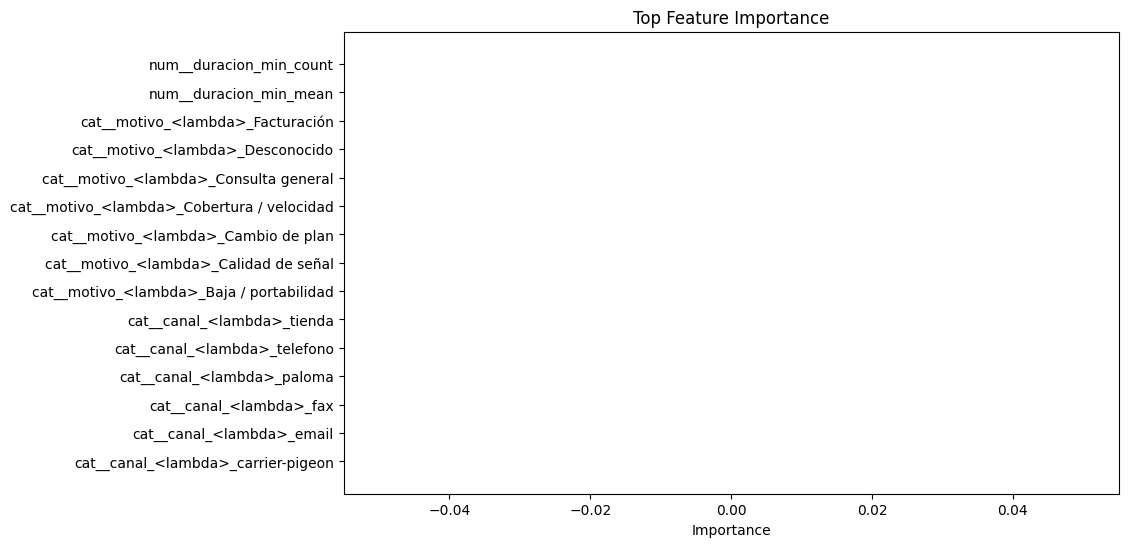


THRESHOLD ANALYSIS
    threshold  precision  recall   f1
0        0.10        0.0     0.0  0.0
1        0.15        0.0     0.0  0.0
2        0.20        0.0     0.0  0.0
3        0.25        0.0     0.0  0.0
4        0.30        0.0     0.0  0.0
5        0.35        0.0     0.0  0.0
6        0.40        0.0     0.0  0.0
7        0.45        0.0     0.0  0.0
8        0.50        0.0     0.0  0.0
9        0.55        0.0     0.0  0.0
10       0.60        0.0     0.0  0.0
11       0.65        0.0     0.0  0.0
12       0.70        0.0     0.0  0.0
13       0.75        0.0     0.0  0.0
14       0.80        0.0     0.0  0.0
15       0.85        0.0     0.0  0.0

PREDICCIÓN NUEVO CLIENTE
Threshold usado: 0.3
Probabilidad churn: 0.0247
BAJO riesgo de churn


In [ ]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# SIN DATA LEAKAGE
# VERSION FINAL ESTABLE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])
df['mes'] = pd.to_datetime(df['mes'])

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET REAL SIN LEAKAGE
# ============================================================

first_churn = (
    df[df['ever_churn'] == 1]
    .groupby('cliente_id')['mes']
    .min()
    .reset_index()
)

first_churn.columns = [
    'cliente_id',
    'first_churn_month'
]

df = df.merge(
    first_churn,
    on='cliente_id',
    how='left'
)

df['churn_real_mes'] = np.where(
    df['mes'] == df['first_churn_month'],
    1,
    0
)

# ============================================================
# 5. TARGET FUTURO (MES+1)
# ============================================================

monthly_target = (
    df.groupby(['cliente_id', 'mes'])['churn_real_mes']
    .max()
    .reset_index()
)

monthly_target['target_churn_t1'] = (
    monthly_target
    .groupby('cliente_id')['churn_real_mes']
    .shift(-1)
)

monthly_target['target_churn_t1'] = (
    monthly_target['target_churn_t1']
    .fillna(0)
    .astype(int)
)

# ============================================================
# 6. ELIMINAR VARIABLES SOSPECHOSAS
# ============================================================

safe_columns = [

    'cliente_id',
    'mes',

    'duracion_min',
    'satisfaccion_post',
    'dias_retraso_mes',
    'resuelto',
    'impago_mes',

    'canal',
    'motivo'
]

df = df[safe_columns]

# ============================================================
# 7. FEATURES MENSUALES
# ============================================================

monthly_features = (
    df.groupby(['cliente_id', 'mes'])
    .agg({

        'duracion_min': ['count', 'mean', 'max'],

        'satisfaccion_post': ['mean', 'min'],

        'dias_retraso_mes': ['mean', 'max'],

        'resuelto': ['mean'],

        'impago_mes': ['max'],

        'canal': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown',

        'motivo': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown'
    })
)

monthly_features.columns = [
    '_'.join(col)
    for col in monthly_features.columns
]

monthly_features = monthly_features.reset_index()

# ============================================================
# 8. VARIABLES HISTÓRICAS
# ============================================================

monthly_features = monthly_features.sort_values([
    'cliente_id',
    'mes'
])

monthly_features['calls_3m'] = (
    monthly_features
    .groupby('cliente_id')['duracion_min_count']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .sum()
    )
)

monthly_features['sat_3m'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .mean()
    )
)

monthly_features['delay_3m'] = (
    monthly_features
    .groupby('cliente_id')['dias_retraso_mes_mean']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(3, min_periods=1)
         .mean()
    )
)

monthly_features['delta_sat'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .diff()
)

# ============================================================
# 9. MERGE TARGET
# ============================================================

dataset = monthly_features.merge(

    monthly_target[
        [
            'cliente_id',
            'mes',
            'target_churn_t1'
        ]
    ],

    on=['cliente_id', 'mes'],
    how='left'
)

# ============================================================
# 10. LIMPIEZA
# ============================================================

dataset = dataset.dropna(
    subset=['target_churn_t1']
)

# ============================================================
# 11. FEATURES / TARGET
# ============================================================

TARGET = 'target_churn_t1'

FEATURES = [

    c for c in dataset.columns

    if c not in [
        'cliente_id',
        'mes',
        TARGET
    ]
]

X = dataset[FEATURES]
y = dataset[TARGET]

# ============================================================
# 12. BALANCEO CLASES
# ============================================================

neg = (y == 0).sum()
pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("\n==============================")
print("BALANCEO")
print("==============================")

print(f"Negativos: {neg}")
print(f"Positivos: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# ============================================================
# 13. VARIABLES NUM/CAT
# ============================================================

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

# ============================================================
# 14. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([
    ('imputer',
     SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([

    ('imputer',
     SimpleImputer(strategy='most_frequent')),

    ('onehot',
     OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     numeric_cols),

    ('cat',
     categorical_transformer,
     categorical_cols)
])

# ============================================================
# 15. MODELO
# ============================================================

xgb = XGBClassifier(

    eval_metric='logloss',

    random_state=42,

    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline([

    ('preprocessor', preprocessor),

    ('model', xgb)
])

# ============================================================
# 16. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [100, 300],

    'model__max_depth': [3, 5],

    'model__learning_rate': [0.03, 0.05],

    'model__subsample': [0.8, 1.0],

    'model__colsample_bytree': [0.8, 1.0]
}

# ============================================================
# 17. SPLIT TEMPORAL
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

# ============================================================
# 18. GRID SEARCH
# ============================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='f1',

    cv=tscv,

    verbose=2,

    n_jobs=-1
)

# ============================================================
# 19. TRAINING
# ============================================================

grid_search.fit(X, y)

best_model = grid_search.best_estimator_

# ============================================================
# 20. RESULTADOS GRID SEARCH
# ============================================================

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(grid_search.best_params_)

print("\n==============================")
print("BEST F1")
print("==============================")

print(grid_search.best_score_)

# ============================================================
# 21. THRESHOLD
# ============================================================

THRESHOLD = 0.30

# ============================================================
# 22. MÉTRICAS
# ============================================================

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_model.fit(X_train, y_train)

    y_proba = (
        best_model
        .predict_proba(X_test)[:,1]
    )

    y_pred = (
        y_proba >= THRESHOLD
    ).astype(int)

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ========================================================
    # ROC SAFE
    # ========================================================

    if len(np.unique(y_test)) > 1:

        roc = roc_auc_score(
            y_test,
            y_proba
        )

    else:

        roc = np.nan

        print(
            "WARNING: solo una clase "
            "en y_test"
        )

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    roc_scores.append(roc)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")

    if not np.isnan(roc):
        print(f"ROC-AUC  : {roc:.4f}")

# ============================================================
# 23. RESULTADOS FINALES
# ============================================================

print("\n====================================")
print("RESULTADOS FINALES")
print("====================================")

print(f"Accuracy medio : {np.mean(accuracy_scores):.4f}")

print(f"Precision media: {np.mean(precision_scores):.4f}")

print(f"Recall medio   : {np.mean(recall_scores):.4f}")

print(f"F1 medio       : {np.mean(f1_scores):.4f}")

print(
    f"ROC-AUC medio  : "
    f"{np.nanmean(roc_scores):.4f}"
)

# ============================================================
# 24. MATRIZ CONFUSIÓN
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# 25. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ============================================================
# 26. FEATURE IMPORTANCE
# ============================================================

feature_names = (
    best_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

importances = (
    best_model
    .named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({

    'feature': feature_names,

    'importance': importances
})

importance_df = (
    importance_df
    .sort_values(
        'importance',
        ascending=False
    )
)

print("\n====================================")
print("TOP FEATURES")
print("====================================")

print(
    importance_df.head(20)
)

# ============================================================
# 27. ROC CURVE SAFE
# ============================================================

if len(np.unique(y_test)) > 1:

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_proba
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC={roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("FPR")
    plt.ylabel("TPR")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

else:

    print(
        "ROC Curve no disponible"
    )

# ============================================================
# 28. PR CURVE SAFE
# ============================================================

if len(np.unique(y_test)) > 1:

    precision_curve, recall_curve, _ = (
        precision_recall_curve(
            y_test,
            y_proba
        )
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel("Recall")
    plt.ylabel("Precision")

    plt.title("PR Curve")

    plt.show()

else:

    print(
        "PR Curve no disponible"
    )

# ============================================================
# 29. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    importance_df.head(15)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.xlabel("Importance")

plt.title("Top Feature Importance")

plt.show()

# ============================================================
# 30. THRESHOLD ANALYSIS
# ============================================================

thresholds_test = np.arange(
    0.1,
    0.9,
    0.05
)

threshold_results = []

for t in thresholds_test:

    preds_t = (
        y_proba >= t
    ).astype(int)

    threshold_results.append({

        'threshold': t,

        'precision': precision_score(
            y_test,
            preds_t,
            zero_division=0
        ),

        'recall': recall_score(
            y_test,
            preds_t,
            zero_division=0
        ),

        'f1': f1_score(
            y_test,
            preds_t,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

print("\n====================================")
print("THRESHOLD ANALYSIS")
print("====================================")

print(threshold_df)

# ============================================================
# 31. ENTRENAMIENTO FINAL
# ============================================================

best_model.fit(X, y)

# ============================================================
# 32. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],

    'duracion_min_mean': [6.2],

    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],

    'satisfaccion_post_min': [1],

    'dias_retraso_mes_mean': [18],

    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'canal_<lambda>': ['telefono'],

    'motivo_<lambda>': ['Facturación'],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 33. PREDICCIÓN
# ============================================================

probabilidad = (
    best_model
    .predict_proba(nuevo_cliente)[:,1][0]
)

prediccion = int(
    probabilidad >= THRESHOLD
)

# ============================================================
# 34. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(f"Threshold usado: {THRESHOLD}")

print(
    f"Probabilidad churn: "
    f"{probabilidad:.4f}"
)

if prediccion == 1:

    print("ALTO riesgo de churn")

else:

    print("BAJO riesgo de churn")

# PRUEBA 3 (BALANCEANDO)


BALANCEO
Negativos: 157322
Positivos: 18694
scale_pos_weight: 8.42
Fitting 5 folds for each of 48 candidates, totalling 240 fits

BEST PARAMETERS
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}

BEST SCORE
0.2745145882826895

MÉTRICAS POR FOLD

========== FOLD 1 ==========
Accuracy : 0.3541
Precision: 0.1329
Recall   : 0.8952
F1 Score : 0.2315
ROC-AUC  : 0.6756

========== FOLD 2 ==========
Accuracy : 0.3205
Precision: 0.1255
Recall   : 0.9190
F1 Score : 0.2209
ROC-AUC  : 0.6781

========== FOLD 3 ==========
Accuracy : 0.2933
Precision: 0.1234
Recall   : 0.9479
F1 Score : 0.2183
ROC-AUC  : 0.6994

========== FOLD 4 ==========
Accuracy : 0.2735
Precision: 0.1253
Recall   : 0.9620
F1 Score : 0.2218
ROC-AUC  : 0.7107

========== FOLD 5 ==========
Accuracy : 0.2797
Precision: 0.1250
Recall   : 0.9542
F1 Score : 0.2210
ROC-AUC  : 0.7047

MÉTRICAS GLOBALES
Accuracy            : 0.2797
Balanced Accurac

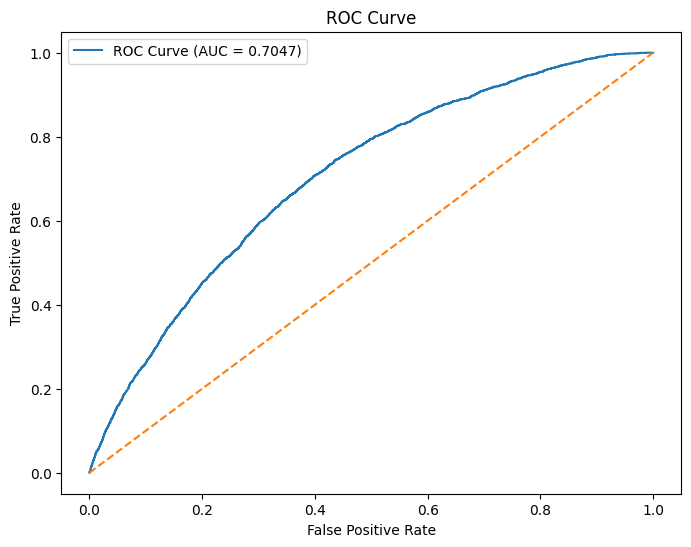

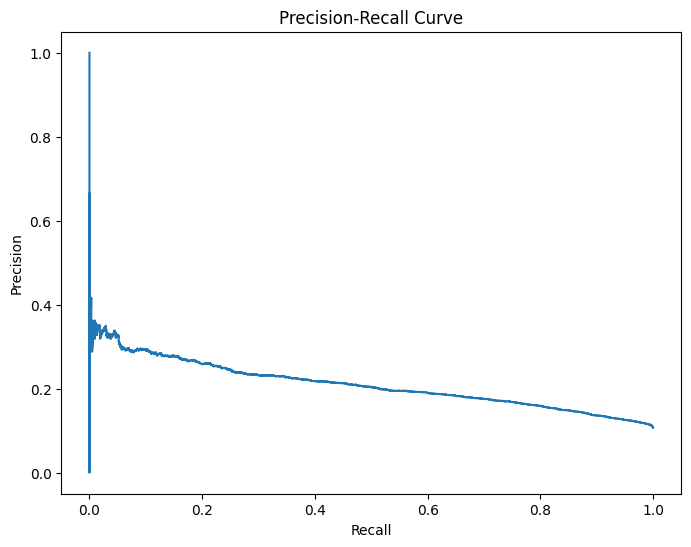


TOP FEATURES


NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# BALANCEADO + THRESHOLD OPTIMIZADO
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(df['fecha_evento'])
df['mes'] = pd.to_datetime(df['mes'])

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET FUTURO (MES+1)
# ============================================================

monthly_target = (
    df.groupby(['cliente_id', 'mes'])['ever_churn']
    .max()
    .reset_index()
)

monthly_target['target_churn_t1'] = (
    monthly_target
    .groupby('cliente_id')['ever_churn']
    .shift(-1)
)

monthly_target['target_churn_t1'] = (
    monthly_target['target_churn_t1']
    .fillna(0)
    .astype(int)
)

# ============================================================
# 5. FEATURES MENSUALES
# ============================================================

monthly_features = (
    df.groupby(['cliente_id', 'mes'])
    .agg({
        'duracion_min': ['count', 'mean', 'max'],
        'satisfaccion_post': ['mean', 'min'],
        'stress_calidad_lag': ['mean'],
        'dias_retraso_mes': ['mean', 'max'],
        'resuelto': ['mean'],
        'impago_mes': ['max'],
        'incidencia_masiva_lag': ['max']
    })
)

monthly_features.columns = [
    '_'.join(col)
    for col in monthly_features.columns
]

monthly_features = monthly_features.reset_index()

# ============================================================
# 6. VARIABLES HISTÓRICAS
# ============================================================

monthly_features = monthly_features.sort_values([
    'cliente_id',
    'mes'
])

monthly_features['calls_3m'] = (
    monthly_features
    .groupby('cliente_id')['duracion_min_count']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).sum()
    )
)

monthly_features['sat_3m'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['stress_3m'] = (
    monthly_features
    .groupby('cliente_id')['stress_calidad_lag_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['delay_3m'] = (
    monthly_features
    .groupby('cliente_id')['dias_retraso_mes_mean']
    .transform(
        lambda x: x.shift(1).rolling(3, min_periods=1).mean()
    )
)

monthly_features['delta_sat'] = (
    monthly_features
    .groupby('cliente_id')['satisfaccion_post_mean']
    .diff()
)

# ============================================================
# 7. MERGE TARGET
# ============================================================

dataset = monthly_features.merge(
    monthly_target[
        [
            'cliente_id',
            'mes',
            'target_churn_t1'
        ]
    ],
    on=['cliente_id', 'mes'],
    how='left'
)

# ============================================================
# 8. ELIMINAR LEAKAGE
# ============================================================

dataset = dataset.drop(
    columns=['ever_churn'],
    errors='ignore'
)

# ============================================================
# 9. LIMPIEZA
# ============================================================

dataset = dataset.dropna(
    subset=['target_churn_t1']
)

# ============================================================
# 10. FEATURES / TARGET
# ============================================================

TARGET = 'target_churn_t1'

FEATURES = [
    c for c in dataset.columns
    if c not in [
        'cliente_id',
        'mes',
        TARGET
    ]
]

X = dataset[FEATURES]
y = dataset[TARGET]

# ============================================================
# 11. BALANCEO CLASES
# ============================================================

neg = (y == 0).sum()
pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("\n==============================")
print("BALANCEO")
print("==============================")
print(f"Negativos: {neg}")
print(f"Positivos: {pos}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# ============================================================
# 12. VARIABLES NUM/CAT
# ============================================================

categorical_cols = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numeric_cols = X.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

# ============================================================
# 13. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# ============================================================
# 14. MODELO BASE
# ============================================================

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb)
])

# ============================================================
# 15. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [100, 300],

    'model__max_depth': [3, 5],

    'model__learning_rate': [0.03, 0.05, 0.1],

    'model__subsample': [0.8, 1.0],

    'model__colsample_bytree': [0.8, 1.0]
}

# ============================================================
# 16. TIME SERIES SPLIT
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

# ============================================================
# 17. GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

# ============================================================
# 18. TRAINING
# ============================================================

grid_search.fit(X, y)

# ============================================================
# 19. BEST MODEL
# ============================================================

best_model = grid_search.best_estimator_

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(grid_search.best_params_)

print("\n==============================")
print("BEST SCORE")
print("==============================")

print(grid_search.best_score_)

# ============================================================
# 20. THRESHOLD
# ============================================================

THRESHOLD = 0.30

# ============================================================
# 21. EVALUACIÓN MANUAL POR FOLD
# ============================================================

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
roc_scores = []

print("\n==============================")
print("MÉTRICAS POR FOLD")
print("==============================")

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    best_model.fit(X_train, y_train)

    y_proba = best_model.predict_proba(X_test)[:,1]

    # ========================================================
    # THRESHOLD CUSTOM
    # ========================================================

    y_pred = (y_proba >= THRESHOLD).astype(int)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    acc = accuracy_score(y_test, y_pred)

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc = roc_auc_score(y_test, y_proba)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    roc_scores.append(roc)

    print(f"\n========== FOLD {fold+1} ==========")

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")

# ============================================================
# MÉTRICAS COMPLETAS
# ============================================================

from sklearn.metrics import (
    balanced_accuracy_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

# ============================================================
# MÉTRICAS GLOBALES
# ============================================================

print("\n====================================")
print("MÉTRICAS GLOBALES")
print("====================================")

balanced_acc = balanced_accuracy_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_proba)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

specificity = tn / (tn + fp)

print(f"Accuracy            : {accuracy_score(y_test, y_pred):.4f}")

print(f"Balanced Accuracy   : {balanced_acc:.4f}")

print(f"Precision           : {precision_score(y_test, y_pred, zero_division=0):.4f}")

print(f"Recall              : {recall_score(y_test, y_pred, zero_division=0):.4f}")

print(f"Specificity         : {specificity:.4f}")

print(f"F1 Score            : {f1_score(y_test, y_pred, zero_division=0):.4f}")

print(f"ROC-AUC             : {roc_auc_score(y_test, y_proba):.4f}")

print(f"PR-AUC              : {pr_auc:.4f}")

# ============================================================
# MATRIZ CONFUSIÓN
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ============================================================
# ROC CURVE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================

print("\n====================================")
print("TOP FEATURES")
print("====================================")

# sacar nombres columnas transformadas
feature_names = (
    numeric_cols +
    list(
        best_model.named_steps[
            'preprocessor'
        ]
        .transformers_[1][1]
        .named_steps['onehot']
        .get_feature_names_out(categorical_cols)
    )
)

importances = (
    best_model.named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(20))

# ============================================================
# PLOT FEATURE IMPORTANCE
# ============================================================

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['feature'][::-1],
    top_features['importance'][::-1]
)

plt.title("Top Feature Importance")

plt.xlabel("Importance")

plt.show()

# ============================================================
# DISTRIBUCIÓN PROBABILIDADES
# ============================================================

plt.figure(figsize=(8,6))

plt.hist(
    y_proba[y_test == 0],
    bins=30,
    alpha=0.6,
    label='No Churn'
)

plt.hist(
    y_proba[y_test == 1],
    bins=30,
    alpha=0.6,
    label='Churn'
)

plt.xlabel("Predicted Probability")

plt.ylabel("Count")

plt.title("Probability Distribution")

plt.legend()

plt.show()

# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

thresholds_test = np.arange(0.1, 0.9, 0.05)

threshold_results = []

for t in thresholds_test:

    preds_t = (y_proba >= t).astype(int)

    threshold_results.append({
        'threshold': t,
        'precision': precision_score(
            y_test,
            preds_t,
            zero_division=0
        ),
        'recall': recall_score(
            y_test,
            preds_t,
            zero_division=0
        ),
        'f1': f1_score(
            y_test,
            preds_t,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_results)

print("\n====================================")
print("THRESHOLD ANALYSIS")
print("====================================")

print(threshold_df)



In [ ]:
# ============================================================
# 22. RESULTADOS FINALES
# ============================================================

print("\n====================================")
print("RESULTADOS FINALES")
print("====================================")

print(f"Accuracy medio : {np.mean(accuracy_scores):.4f}")
print(f"Precision media: {np.mean(precision_scores):.4f}")
print(f"Recall medio   : {np.mean(recall_scores):.4f}")
print(f"F1 medio       : {np.mean(f1_scores):.4f}")
print(f"ROC-AUC medio  : {np.mean(roc_scores):.4f}")

# ============================================================
# 23. MATRIZ CONFUSIÓN FINAL
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(y_test, y_pred)

print(cm)

# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

# ============================================================
# 25. ENTRENAMIENTO FINAL
# ============================================================

best_model.fit(X, y)

# ============================================================
# 26. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],
    'duracion_min_mean': [6.2],
    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],
    'satisfaccion_post_min': [1],

    'stress_calidad_lag_mean': [0.72],

    'dias_retraso_mes_mean': [18],
    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'incidencia_masiva_lag_max': [1],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'stress_3m': [0.65],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 27. PREDICCIÓN FUTURA
# ============================================================

probabilidad = best_model.predict_proba(
    nuevo_cliente
)[:,1][0]

prediccion = int(probabilidad >= THRESHOLD)

# ============================================================
# 28. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(f"Threshold usado: {THRESHOLD}")
print(f"Probabilidad churn: {probabilidad:.4f}")

if prediccion == 1:
    print("ALTO riesgo de churn")
else:
    print("BAJO riesgo de churn")

# ultimo


TARGET DISTRIBUTION
target_churn_max
0    174043
1      1973
Name: count, dtype: int64

BALANCEO
Negativos: 174043
Positivos: 1973
scale_pos_weight: 88.21
Fitting 5 folds for each of 32 candidates, totalling 160 fits

BEST PARAMETERS
{'model__colsample_bytree': 1.0, 'model__learning_rate': 0.03, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 0.8}

BEST F1
0.3326206695115458

========== FOLD 1 ==========
Accuracy           : 0.9563
Balanced Accuracy  : 0.9674
Precision          : 0.2011
Recall             : 0.9787
F1 Score           : 0.3337
ROC-AUC            : 0.9779
PR-AUC             : 0.2029

========== FOLD 2 ==========
Accuracy           : 0.9552
Balanced Accuracy  : 0.9715
Precision          : 0.2022
Recall             : 0.9881
F1 Score           : 0.3357
ROC-AUC            : 0.9773
PR-AUC             : 0.1995

========== FOLD 3 ==========
Accuracy           : 0.9550
Balanced Accuracy  : 0.9743
Precision          : 0.2007
Recall             : 0.9940
F1 S

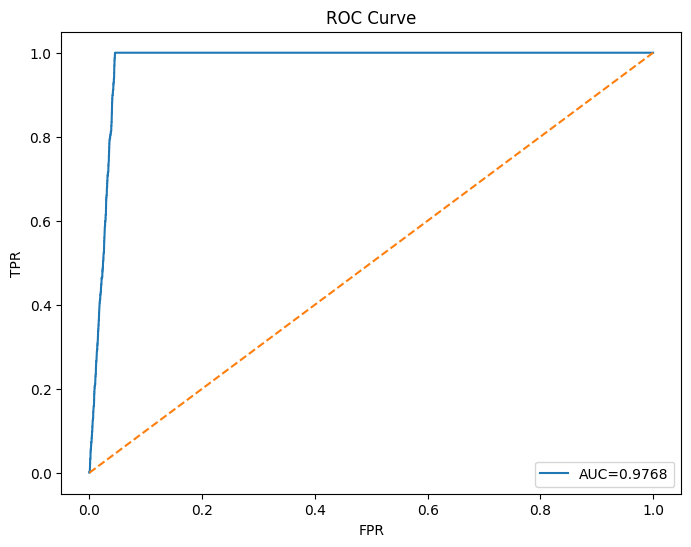

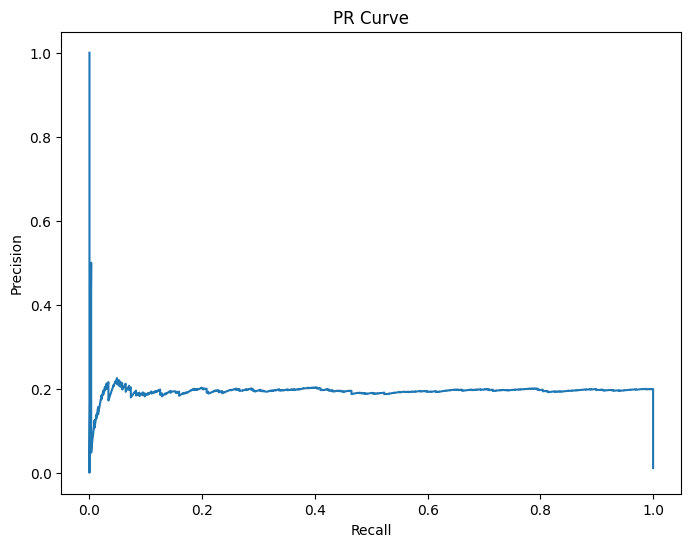

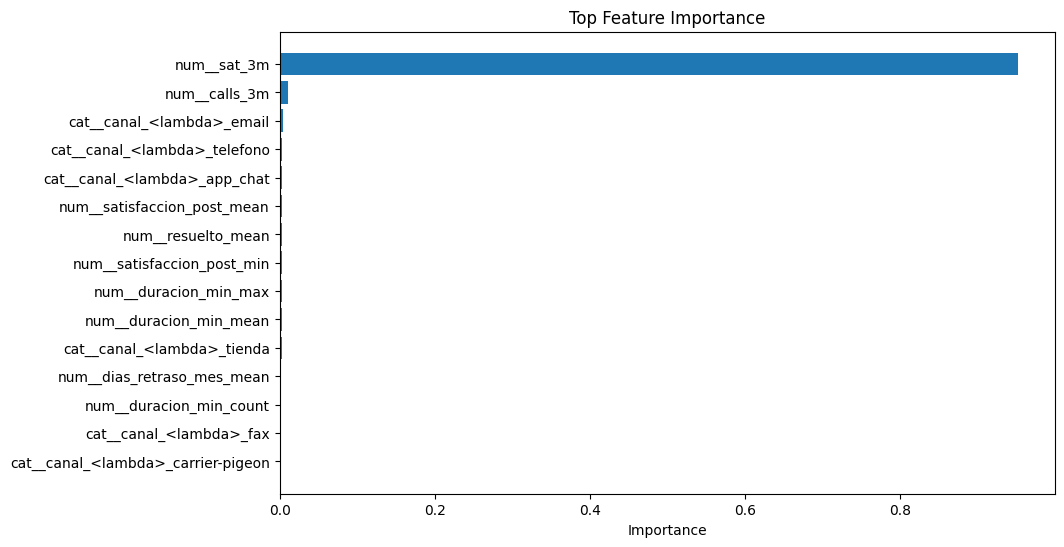


PREDICCIÓN NUEVO CLIENTE
Probabilidad churn: 0.0001
BAJO riesgo de churn


In [ ]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# SIN DATA LEAKAGE
# SIN VARIABLE "motivo"
# MÉTRICAS AVG COMPLETAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc,
    balanced_accuracy_score,
    average_precision_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(
    df['fecha_evento']
)

df['mes'] = pd.to_datetime(
    df['mes']
)

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET REAL
# ============================================================

first_churn = (

    df[df['ever_churn'] == 1]

    .groupby('cliente_id')['mes']

    .min()

    .reset_index()
)

first_churn.columns = [
    'cliente_id',
    'first_churn_month'
]

df = df.merge(
    first_churn,
    on='cliente_id',
    how='left'
)

# ============================================================
# TARGET
# ============================================================

df['target_churn'] = np.where(
    df['mes'] == df['first_churn_month'],
    1,
    0
)

# ============================================================
# 5. VARIABLES SEGURAS
# ============================================================

safe_columns = [

    'cliente_id',
    'mes',

    'duracion_min',
    'satisfaccion_post',
    'dias_retraso_mes',
    'resuelto',
    'impago_mes',

    'canal',

    'target_churn'
]

df = df[safe_columns]

# ============================================================
# 6. FEATURES MENSUALES
# ============================================================

monthly_features = (

    df.groupby(['cliente_id', 'mes'])

    .agg({

        'duracion_min': [
            'count',
            'mean',
            'max'
        ],

        'satisfaccion_post': [
            'mean',
            'min'
        ],

        'dias_retraso_mes': [
            'mean',
            'max'
        ],

        'resuelto': [
            'mean'
        ],

        'impago_mes': [
            'max'
        ],

        'canal': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown',

        'target_churn': [
            'max'
        ]
    })
)

monthly_features.columns = [

    '_'.join(col)

    for col in monthly_features.columns
]

monthly_features = (
    monthly_features
    .reset_index()
)

# ============================================================
# 7. FEATURES HISTÓRICAS
# ============================================================

monthly_features = (

    monthly_features

    .sort_values([
        'cliente_id',
        'mes'
    ])
)

monthly_features['calls_3m'] = (

    monthly_features

    .groupby('cliente_id')['duracion_min_count']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .sum()
    )
)

monthly_features['sat_3m'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delay_3m'] = (

    monthly_features

    .groupby('cliente_id')['dias_retraso_mes_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delta_sat'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .diff()
)

# ============================================================
# 8. DATASET FINAL
# ============================================================

dataset = monthly_features.copy()

# ============================================================
# 9. TARGET / FEATURES
# ============================================================

TARGET = 'target_churn_max'

FEATURES = [

    c for c in dataset.columns

    if c not in [
        'cliente_id',
        'mes',
        TARGET
    ]
]

X = dataset[FEATURES]

y = dataset[TARGET]

# ============================================================
# 10. DISTRIBUCIÓN TARGET
# ============================================================

print("\n==============================")
print("TARGET DISTRIBUTION")
print("==============================")

print(y.value_counts())

# ============================================================
# 11. BALANCEO
# ============================================================

neg = (y == 0).sum()

pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("\n==============================")
print("BALANCEO")
print("==============================")

print(f"Negativos: {neg}")

print(f"Positivos: {pos}")

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.2f}"
)

# ============================================================
# 12. VARIABLES NUM/CAT
# ============================================================

categorical_cols = (

    X.select_dtypes(

        include=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

numeric_cols = (

    X.select_dtypes(

        exclude=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

# ============================================================
# 13. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='median'
     ))
])

categorical_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='most_frequent'
     )),

    ('onehot',

     OneHotEncoder(
         handle_unknown='ignore'
     ))
])

preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     numeric_cols),

    ('cat',
     categorical_transformer,
     categorical_cols)
])

# ============================================================
# 14. MODELO
# ============================================================

xgb = XGBClassifier(

    eval_metric='logloss',

    random_state=42,

    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline([

    ('preprocessor',
     preprocessor),

    ('model',
     xgb)
])

# ============================================================
# 15. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [
        100,
        300
    ],

    'model__max_depth': [
        3,
        5
    ],

    'model__learning_rate': [
        0.03,
        0.05
    ],

    'model__subsample': [
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.8,
        1.0
    ]
}

# ============================================================
# 16. TIME SERIES SPLIT
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

# ============================================================
# 17. GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='f1',

    cv=tscv,

    verbose=2,

    n_jobs=-1
)

# ============================================================
# 18. TRAINING
# ============================================================

grid_search.fit(X, y)

best_model = (
    grid_search.best_estimator_
)

# ============================================================
# 19. BEST RESULTS
# ============================================================

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(
    grid_search.best_params_
)

print("\n==============================")
print("BEST F1")
print("==============================")

print(
    grid_search.best_score_
)

# ============================================================
# 20. THRESHOLD
# ============================================================

THRESHOLD = 0.50

# ============================================================
# 21. MÉTRICAS POR FOLD
# ============================================================

accuracy_scores = []
balanced_accuracy_scores = []

precision_scores = []
recall_scores = []

f1_scores = []

roc_scores = []

pr_auc_scores = []

for fold, (
    train_idx,
    test_idx
) in enumerate(tscv.split(X)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_train = X.iloc[train_idx]

    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    y_test = y.iloc[test_idx]

    best_model.fit(
        X_train,
        y_train
    )

    y_proba = (

        best_model

        .predict_proba(
            X_test
        )[:,1]
    )

    y_pred = (
        y_proba >= THRESHOLD
    ).astype(int)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    acc = accuracy_score(
        y_test,
        y_pred
    )

    bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ========================================================
    # ROC SAFE
    # ========================================================

    if len(np.unique(y_test)) > 1:

        roc = roc_auc_score(
            y_test,
            y_proba
        )

        pr_auc = average_precision_score(
            y_test,
            y_proba
        )

    else:

        roc = np.nan
        pr_auc = np.nan

    accuracy_scores.append(acc)

    balanced_accuracy_scores.append(
        bal_acc
    )

    precision_scores.append(prec)

    recall_scores.append(rec)

    f1_scores.append(f1)

    roc_scores.append(roc)

    pr_auc_scores.append(pr_auc)

    print(f"Accuracy           : {acc:.4f}")

    print(f"Balanced Accuracy  : {bal_acc:.4f}")

    print(f"Precision          : {prec:.4f}")

    print(f"Recall             : {rec:.4f}")

    print(f"F1 Score           : {f1:.4f}")

    if not np.isnan(roc):

        print(f"ROC-AUC            : {roc:.4f}")

        print(f"PR-AUC             : {pr_auc:.4f}")

# ============================================================
# 22. MÉTRICAS AVG COMPLETAS
# ============================================================

print("\n====================================")
print("AVG METRICS")
print("====================================")

print(
    f"Accuracy AVG            : "
    f"{np.mean(accuracy_scores):.4f}"
)

print(
    f"Balanced Accuracy AVG   : "
    f"{np.mean(balanced_accuracy_scores):.4f}"
)

print(
    f"Precision AVG           : "
    f"{np.mean(precision_scores):.4f}"
)

print(
    f"Recall AVG              : "
    f"{np.mean(recall_scores):.4f}"
)

print(
    f"F1 Score AVG            : "
    f"{np.mean(f1_scores):.4f}"
)

print(
    f"ROC-AUC AVG             : "
    f"{np.nanmean(roc_scores):.4f}"
)

print(
    f"PR-AUC AVG              : "
    f"{np.nanmean(pr_auc_scores):.4f}"
)

# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0
    )
)

# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

feature_names = (

    best_model

    .named_steps['preprocessor']

    .get_feature_names_out()
)

importances = (

    best_model

    .named_steps['model']

    .feature_importances_
)

importance_df = pd.DataFrame({

    'feature': feature_names,

    'importance': importances
})

importance_df = (

    importance_df

    .sort_values(
        'importance',
        ascending=False
    )
)

print("\n====================================")
print("TOP FEATURES")
print("====================================")

print(
    importance_df.head(20)
)

# ============================================================
# 26. ROC CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC={roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("FPR")

    plt.ylabel("TPR")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

# ============================================================
# 27. PR CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    precision_curve, recall_curve, _ = (

        precision_recall_curve(
            y_test,
            y_proba
        )
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("PR Curve")

    plt.show()

# ============================================================
# 28. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    importance_df.head(15)
)

plt.figure(figsize=(10,6))

plt.barh(

    top_features['feature'][::-1],

    top_features['importance'][::-1]
)

plt.xlabel("Importance")

plt.title(
    "Top Feature Importance"
)

plt.show()

# ============================================================
# 29. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],

    'duracion_min_mean': [6.2],

    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],

    'satisfaccion_post_min': [1],

    'dias_retraso_mes_mean': [18],

    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'canal_<lambda>': ['telefono'],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 30. PREDICCIÓN
# ============================================================

probabilidad = (

    best_model

    .predict_proba(
        nuevo_cliente
    )[:,1][0]
)

prediccion = int(
    probabilidad >= THRESHOLD
)

# ============================================================
# 31. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(
    f"Probabilidad churn: "
    f"{probabilidad:.4f}"
)

if prediccion == 1:

    print("ALTO riesgo de churn")

else:

    print("BAJO riesgo de churn")


TARGET DISTRIBUTION
target_churn_max
0    174043
1      1973
Name: count, dtype: int64

BALANCEO
Negativos: 174043
Positivos: 1973
scale_pos_weight: 88.21
Fitting 5 folds for each of 32 candidates, totalling 160 fits

BEST PARAMETERS
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 1.0}

BEST F1
0.22986370483531565

========== FOLD 1 ==========
Accuracy           : 0.9491
Balanced Accuracy  : 0.8070
Precision          : 0.1357
Recall             : 0.6616
F1 Score           : 0.2252
ROC-AUC            : 0.9651
PR-AUC             : 0.1537

========== FOLD 2 ==========
Accuracy           : 0.9357
Balanced Accuracy  : 0.8689
Precision          : 0.1288
Recall             : 0.8006
F1 Score           : 0.2219
ROC-AUC            : 0.9620
PR-AUC             : 0.1406

========== FOLD 3 ==========
Accuracy           : 0.9322
Balanced Accuracy  : 0.9167
Precision          : 0.1330
Recall             : 0.9009
F1 

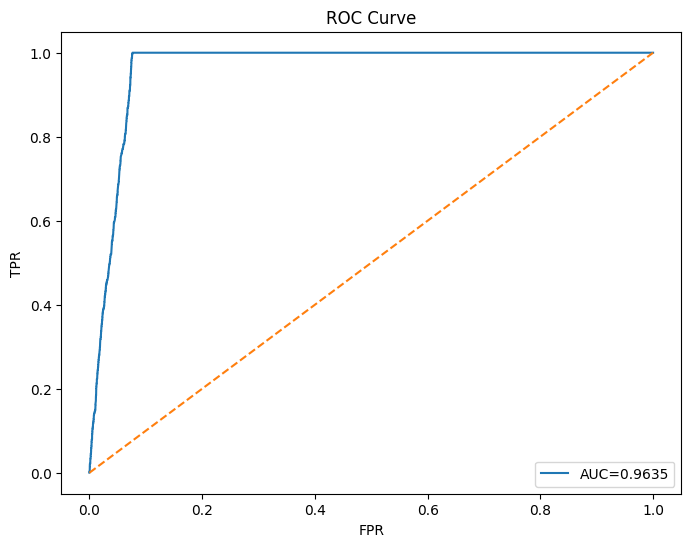

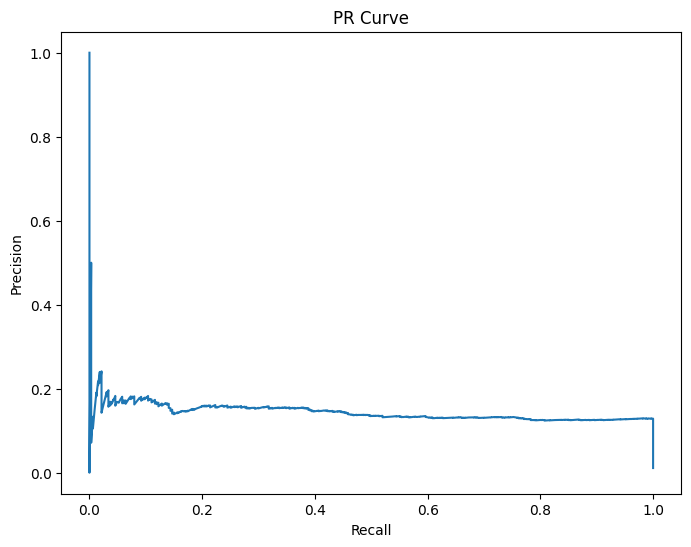

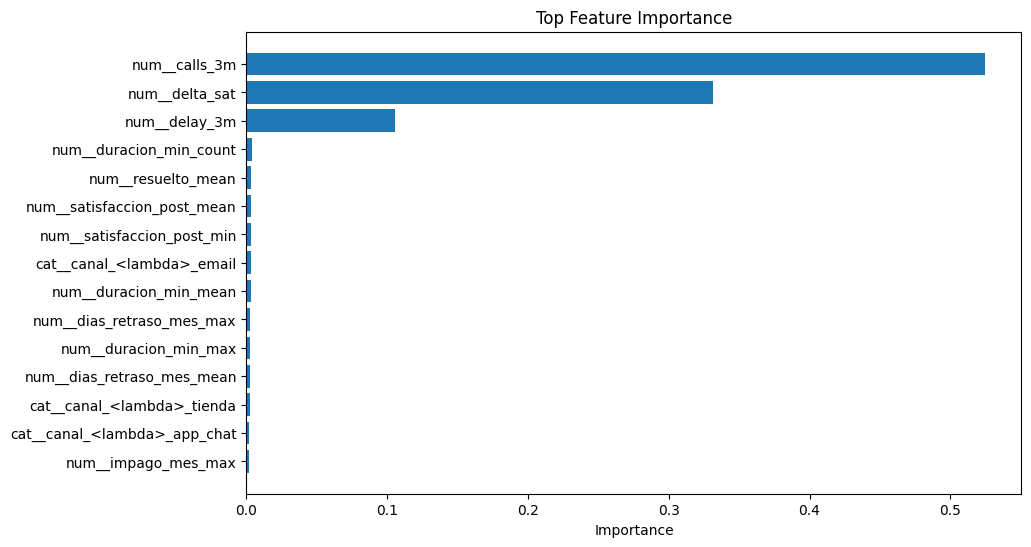


PREDICCIÓN NUEVO CLIENTE
Probabilidad churn: 0.0000
BAJO riesgo de churn


In [ ]:
# ============================================================
# CHURN PREDICTION REAL
# XGBOOST + GRID SEARCH + TIME SERIES CV
# SIN DATA LEAKAGE
# SIN VARIABLE "motivo"
# MÉTRICAS AVG COMPLETAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    auc,
    balanced_accuracy_score,
    average_precision_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier

# ============================================================
# 1. DATASET
# ============================================================

df = soporte_churn.copy()

# ============================================================
# 2. FECHAS
# ============================================================

df['fecha_evento'] = pd.to_datetime(
    df['fecha_evento']
)

df['mes'] = pd.to_datetime(
    df['mes']
)

# ============================================================
# 3. ORDEN TEMPORAL
# ============================================================

df = df.sort_values([
    'cliente_id',
    'fecha_evento'
])

# ============================================================
# 4. TARGET REAL
# ============================================================

first_churn = (

    df[df['ever_churn'] == 1]

    .groupby('cliente_id')['mes']

    .min()

    .reset_index()
)

first_churn.columns = [
    'cliente_id',
    'first_churn_month'
]

df = df.merge(
    first_churn,
    on='cliente_id',
    how='left'
)

# ============================================================
# TARGET
# ============================================================

df['target_churn'] = np.where(
    df['mes'] == df['first_churn_month'],
    1,
    0
)

# ============================================================
# 5. VARIABLES SEGURAS
# ============================================================

safe_columns = [

    'cliente_id',
    'mes',

    'duracion_min',
    'satisfaccion_post',
    'dias_retraso_mes',
    'resuelto',
    'impago_mes',

    'canal',

    'target_churn'
]

df = df[safe_columns]

# ============================================================
# 6. FEATURES MENSUALES
# ============================================================

monthly_features = (

    df.groupby(['cliente_id', 'mes'])

    .agg({

        'duracion_min': [
            'count',
            'mean',
            'max'
        ],

        'satisfaccion_post': [
            'mean',
            'min'
        ],

        'dias_retraso_mes': [
            'mean',
            'max'
        ],

        'resuelto': [
            'mean'
        ],

        'impago_mes': [
            'max'
        ],

        'canal': lambda x:
            x.mode()[0]
            if len(x.mode()) > 0
            else 'unknown',

        'target_churn': [
            'max'
        ]
    })
)

monthly_features.columns = [

    '_'.join(col)

    for col in monthly_features.columns
]

monthly_features = (
    monthly_features
    .reset_index()
)

# ============================================================
# 7. FEATURES HISTÓRICAS
# ============================================================

monthly_features = (

    monthly_features

    .sort_values([
        'cliente_id',
        'mes'
    ])
)

monthly_features['calls_3m'] = (

    monthly_features

    .groupby('cliente_id')['duracion_min_count']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .sum()
    )
)

monthly_features['sat_3m'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delay_3m'] = (

    monthly_features

    .groupby('cliente_id')['dias_retraso_mes_mean']

    .transform(

        lambda x:

        x.shift(1)

         .rolling(
             3,
             min_periods=1
         )

         .mean()
    )
)

monthly_features['delta_sat'] = (

    monthly_features

    .groupby('cliente_id')['satisfaccion_post_mean']

    .diff()
)

# ============================================================
# 8. DATASET FINAL
# ============================================================

dataset = monthly_features.copy()

# ============================================================
# 9. TARGET / FEATURES
# ============================================================

TARGET = 'target_churn_max'

FEATURES = [

    c for c in dataset.columns

    if c not in [
        'cliente_id',
        'mes',
        TARGET,
        'sat_3m'
    ]
]

X = dataset[FEATURES]

y = dataset[TARGET]

# ============================================================
# 10. DISTRIBUCIÓN TARGET
# ============================================================

print("\n==============================")
print("TARGET DISTRIBUTION")
print("==============================")

print(y.value_counts())

# ============================================================
# 11. BALANCEO
# ============================================================

neg = (y == 0).sum()

pos = (y == 1).sum()

scale_pos_weight = neg / pos

print("\n==============================")
print("BALANCEO")
print("==============================")

print(f"Negativos: {neg}")

print(f"Positivos: {pos}")

print(
    f"scale_pos_weight: "
    f"{scale_pos_weight:.2f}"
)

# ============================================================
# 12. VARIABLES NUM/CAT
# ============================================================

categorical_cols = (

    X.select_dtypes(

        include=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

numeric_cols = (

    X.select_dtypes(

        exclude=[
            'object',
            'category'
        ]

    ).columns.tolist()
)

# ============================================================
# 13. PREPROCESS
# ============================================================

numeric_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='median'
     ))
])

categorical_transformer = Pipeline([

    ('imputer',

     SimpleImputer(
         strategy='most_frequent'
     )),

    ('onehot',

     OneHotEncoder(
         handle_unknown='ignore'
     ))
])

preprocessor = ColumnTransformer([

    ('num',
     numeric_transformer,
     numeric_cols),

    ('cat',
     categorical_transformer,
     categorical_cols)
])

# ============================================================
# 14. MODELO
# ============================================================

xgb = XGBClassifier(

    eval_metric='logloss',

    random_state=42,

    scale_pos_weight=scale_pos_weight
)

pipeline = Pipeline([

    ('preprocessor',
     preprocessor),

    ('model',
     xgb)
])

# ============================================================
# 15. GRID SEARCH
# ============================================================

param_grid = {

    'model__n_estimators': [
        100,
        300
    ],

    'model__max_depth': [
        3,
        5
    ],

    'model__learning_rate': [
        0.03,
        0.05
    ],

    'model__subsample': [
        0.8,
        1.0
    ],

    'model__colsample_bytree': [
        0.8,
        1.0
    ]
}

# ============================================================
# 16. TIME SERIES SPLIT
# ============================================================

tscv = TimeSeriesSplit(
    n_splits=5
)

# ============================================================
# 17. GRID SEARCH CV
# ============================================================

grid_search = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    scoring='f1',

    cv=tscv,

    verbose=2,

    n_jobs=-1
)

# ============================================================
# 18. TRAINING
# ============================================================

grid_search.fit(X, y)

best_model = (
    grid_search.best_estimator_
)

# ============================================================
# 19. BEST RESULTS
# ============================================================

print("\n==============================")
print("BEST PARAMETERS")
print("==============================")

print(
    grid_search.best_params_
)

print("\n==============================")
print("BEST F1")
print("==============================")

print(
    grid_search.best_score_
)

# ============================================================
# 20. THRESHOLD
# ============================================================

THRESHOLD = 0.80

# ============================================================
# 21. MÉTRICAS POR FOLD
# ============================================================

accuracy_scores = []
balanced_accuracy_scores = []

precision_scores = []
recall_scores = []

f1_scores = []

roc_scores = []

pr_auc_scores = []

for fold, (
    train_idx,
    test_idx
) in enumerate(tscv.split(X)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_train = X.iloc[train_idx]

    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]

    y_test = y.iloc[test_idx]

    best_model.fit(
        X_train,
        y_train
    )

    y_proba = (

        best_model

        .predict_proba(
            X_test
        )[:,1]
    )

    y_pred = (
        y_proba >= THRESHOLD
    ).astype(int)

    # ========================================================
    # MÉTRICAS
    # ========================================================

    acc = accuracy_score(
        y_test,
        y_pred
    )

    bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    prec = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    rec = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    # ========================================================
    # ROC SAFE
    # ========================================================

    if len(np.unique(y_test)) > 1:

        roc = roc_auc_score(
            y_test,
            y_proba
        )

        pr_auc = average_precision_score(
            y_test,
            y_proba
        )

    else:

        roc = np.nan
        pr_auc = np.nan

    accuracy_scores.append(acc)

    balanced_accuracy_scores.append(
        bal_acc
    )

    precision_scores.append(prec)

    recall_scores.append(rec)

    f1_scores.append(f1)

    roc_scores.append(roc)

    pr_auc_scores.append(pr_auc)

    print(f"Accuracy           : {acc:.4f}")

    print(f"Balanced Accuracy  : {bal_acc:.4f}")

    print(f"Precision          : {prec:.4f}")

    print(f"Recall             : {rec:.4f}")

    print(f"F1 Score           : {f1:.4f}")

    if not np.isnan(roc):

        print(f"ROC-AUC            : {roc:.4f}")

        print(f"PR-AUC             : {pr_auc:.4f}")

# ============================================================
# 22. MÉTRICAS AVG COMPLETAS
# ============================================================

print("\n====================================")
print("AVG METRICS")
print("====================================")

print(
    f"Accuracy AVG            : "
    f"{np.mean(accuracy_scores):.4f}"
)

print(
    f"Balanced Accuracy AVG   : "
    f"{np.mean(balanced_accuracy_scores):.4f}"
)

print(
    f"Precision AVG           : "
    f"{np.mean(precision_scores):.4f}"
)

print(
    f"Recall AVG              : "
    f"{np.mean(recall_scores):.4f}"
)

print(
    f"F1 Score AVG            : "
    f"{np.mean(f1_scores):.4f}"
)

print(
    f"ROC-AUC AVG             : "
    f"{np.nanmean(roc_scores):.4f}"
)

print(
    f"PR-AUC AVG              : "
    f"{np.nanmean(pr_auc_scores):.4f}"
)

# ============================================================
# 23. CONFUSION MATRIX
# ============================================================

print("\n====================================")
print("CONFUSION MATRIX")
print("====================================")

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

# ============================================================
# 24. CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("CLASSIFICATION REPORT")
print("====================================")

print(

    classification_report(

        y_test,

        y_pred,

        zero_division=0
    )
)

# ============================================================
# 25. FEATURE IMPORTANCE
# ============================================================

feature_names = (

    best_model

    .named_steps['preprocessor']

    .get_feature_names_out()
)

importances = (

    best_model

    .named_steps['model']

    .feature_importances_
)

importance_df = pd.DataFrame({

    'feature': feature_names,

    'importance': importances
})

importance_df = (

    importance_df

    .sort_values(
        'importance',
        ascending=False
    )
)

print("\n====================================")
print("TOP FEATURES")
print("====================================")

print(
    importance_df.head(20)
)

# ============================================================
# 26. ROC CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    fpr, tpr, _ = roc_curve(
        y_test,
        y_proba
    )

    roc_auc = auc(
        fpr,
        tpr
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC={roc_auc:.4f}'
    )

    plt.plot(
        [0,1],
        [0,1],
        linestyle='--'
    )

    plt.xlabel("FPR")

    plt.ylabel("TPR")

    plt.title("ROC Curve")

    plt.legend()

    plt.show()

# ============================================================
# 27. PR CURVE
# ============================================================

if len(np.unique(y_test)) > 1:

    precision_curve, recall_curve, _ = (

        precision_recall_curve(
            y_test,
            y_proba
        )
    )

    plt.figure(figsize=(8,6))

    plt.plot(
        recall_curve,
        precision_curve
    )

    plt.xlabel("Recall")

    plt.ylabel("Precision")

    plt.title("PR Curve")

    plt.show()

# ============================================================
# 28. FEATURE IMPORTANCE PLOT
# ============================================================

top_features = (
    importance_df.head(15)
)

plt.figure(figsize=(10,6))

plt.barh(

    top_features['feature'][::-1],

    top_features['importance'][::-1]
)

plt.xlabel("Importance")

plt.title(
    "Top Feature Importance"
)

plt.show()

# ============================================================
# 29. NUEVO CLIENTE
# ============================================================

nuevo_cliente = pd.DataFrame({

    'duracion_min_count': [8],

    'duracion_min_mean': [6.2],

    'duracion_min_max': [12],

    'satisfaccion_post_mean': [2.9],

    'satisfaccion_post_min': [1],

    'dias_retraso_mes_mean': [18],

    'dias_retraso_mes_max': [35],

    'resuelto_mean': [0.42],

    'impago_mes_max': [1],

    'canal_<lambda>': ['telefono'],

    'calls_3m': [20],

    'sat_3m': [3.1],

    'delay_3m': [14],

    'delta_sat': [-0.8]
})

# ============================================================
# 30. PREDICCIÓN
# ============================================================

probabilidad = (

    best_model

    .predict_proba(
        nuevo_cliente
    )[:,1][0]
)

prediccion = int(
    probabilidad >= THRESHOLD
)

# ============================================================
# 31. RESULTADO FINAL
# ============================================================

print("\n====================================")
print("PREDICCIÓN NUEVO CLIENTE")
print("====================================")

print(
    f"Probabilidad churn: "
    f"{probabilidad:.4f}"
)

if prediccion == 1:

    print("ALTO riesgo de churn")

else:

    print("BAJO riesgo de churn")